# 18. LaMa Feature Similarity

Refactored CLIP and DINOv2 feature-space similarity evaluation for LaMa restorations.

Origin: existing notebook 15, updated to the current standardized LaMa restoration universe and downstream handoff contract.


## Truth Source And Evaluation Scope

Planned requirements for this notebook:

- compute CLIP similarity;
- compute DINOv2 similarity;
- calculate feature improvement as restored-minus-damaged similarity;
- standardize evaluation regions across metrics;
- retain embedding identifiers for grouped analysis and example-based XAI;
- support later semantic-localization analysis.

Region policy:

- `full_image` for the full restored painting;
- `content_region` for the standardized painting-content crop;
- `mask_bbox_crop` for non-zero masks only.

The notebook deliberately avoids sparse masked-pixel feature metrics because CLIP and DINOv2 consume image-like spatial patches, not unordered pixel sets.


## Batch 1 - Setup, Contracts, And Input Gates

This first batch defines the notebook contract before any expensive model inference. It verifies the helper module, runtime dependencies, upstream metadata, path normalization, and expected output row counts.


In [1]:
from pathlib import Path
import hashlib
import json
import sys
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import yaml
except ImportError:
    yaml = None

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from restoration_eval.metrics_feature_similarity import (
    DEFAULT_CLIP_MODEL_NAME,
    DEFAULT_CLIP_MODEL_REVISION,
    DEFAULT_DINOV2_MODEL_NAME,
    DEFAULT_DINOV2_MODEL_REVISION,
    DEFAULT_FEATURE_INPUT_SIZE,
    DEFAULT_MASK_BBOX_MARGIN,
    DEFAULT_MASK_BINARY_THRESHOLD,
    FEATURE_SIMILARITY_EVALUATION_REGIONS,
    FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
    compute_feature_similarity_for_restorations,
    expected_feature_similarity_region_counts_from_metadata,
    expected_feature_similarity_rows_from_metadata,
    get_device,
    load_clip_model_and_processor,
    load_dinov2_model,
    rank_feature_similarity_cases,
    summarize_feature_similarity_metrics,
    validate_feature_similarity_metrics,
    validate_feature_similarity_runtime_dependencies,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)


def project_relative_path(path: Path | str) -> str:
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_project_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def build_check(check_name, observed, expected, passed, issue="") -> dict:
    return {
        "check_name": check_name,
        "observed": observed,
        "expected": expected,
        "passed": bool(passed),
        "issue": issue if issue else "",
    }


def json_safe(value):
    if isinstance(value, Path):
        return project_relative_path(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)


Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src


In [2]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("jmespath") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jmespath"])

print("jmespath:", importlib.metadata.version("jmespath"))

jmespath: 1.1.0


In [3]:
NOTEBOOK_ID = "18_lama_feature_similarity"
NOTEBOOK_NAME = "18_lama_feature_similarity.ipynb"
MODEL_NAME = "lama"
METRIC_FAMILY = "feature_similarity"

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if CONFIG_PATH.is_file():
    if yaml is None:
        raise RuntimeError("PyYAML is required to read the experiment config.")

    with open(CONFIG_PATH, "r", encoding="utf-8") as config_file:
        config = yaml.safe_load(config_file)

    paths_cfg = config.get("paths", {})
    PROCESSED_METADATA_DIR = PROJECT_ROOT / paths_cfg.get(
        "processed_metadata_dir",
        "data/processed/metadata",
    )
    METRICS_DIR = PROJECT_ROOT / paths_cfg.get("metrics_dir", "outputs/metrics")
    FIGURES_ROOT_DIR = PROJECT_ROOT / paths_cfg.get("figures_dir", "outputs/figures")
else:
    config = {}
    PROCESSED_METADATA_DIR = PROJECT_ROOT / "data" / "processed" / "metadata"
    METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
    FIGURES_ROOT_DIR = PROJECT_ROOT / "outputs" / "figures"

VALIDATION_DIR = PROJECT_ROOT / "outputs" / "validation"
MANIFESTS_DIR = PROJECT_ROOT / "outputs" / "manifests"
FIGURES_DIR = FIGURES_ROOT_DIR / NOTEBOOK_ID

for directory in [METRICS_DIR, VALIDATION_DIR, MANIFESTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LAMA_RESTORATION_MANIFEST_PATH = PROCESSED_METADATA_DIR / "metadata_restored_lama.csv"
PROCESSED_CLEAN_METADATA_PATH = PROCESSED_METADATA_DIR / "metadata_processed_clean.csv"
LPIPS_HANDOFF_MANIFEST_JSON_PATH = METRICS_DIR / "lpips_handoff_manifest_lama.json"
HELPER_MODULE_PATH = SRC_DIR / "restoration_eval" / "metrics_feature_similarity.py"

FEATURE_METRICS_OUTPUT_PATH = METRICS_DIR / "feature_similarity_metrics_lama.csv"
FEATURE_COMPACT_METRICS_OUTPUT_PATH = METRICS_DIR / "feature_similarity_metrics_lama_compact.csv"
FEATURE_OVERALL_SUMMARY_OUTPUT_PATH = METRICS_DIR / "feature_similarity_summary_lama.csv"
FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "feature_similarity_summary_by_dataset_region_lama.csv"
FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "feature_similarity_summary_by_mask_region_lama.csv"
FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH = METRICS_DIR / "feature_similarity_summary_by_category_region_lama.csv"
FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH = METRICS_DIR / "feature_similarity_summary_zero_control_lama.csv"
FEATURE_RANKED_BY_REGION_OUTPUT_PATH = METRICS_DIR / "feature_similarity_ranked_cases_by_region_lama.csv"

FEATURE_SMOKE_METRICS_OUTPUT_PATH = VALIDATION_DIR / "feature_similarity_smoke_lama.csv"
FEATURE_SMOKE_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "feature_similarity_smoke_validation_lama.csv"
FEATURE_FULL_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "feature_similarity_validation_lama.csv"
FEATURE_BATCH1_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "feature_similarity_batch1_validation_lama.csv"
FEATURE_FINAL_VALIDATION_OUTPUT_PATH = VALIDATION_DIR / "feature_similarity_final_validation_lama.csv"

FEATURE_STAGE_MANIFEST_JSON_PATH = MANIFESTS_DIR / "18_lama_feature_similarity_manifest.json"
FEATURE_HANDOFF_MANIFEST_JSON_PATH = METRICS_DIR / "feature_similarity_handoff_manifest_lama.json"

FEATURE_DIAGNOSTIC_FIGURES_DIR = FIGURES_DIR / "feature_similarity_diagnostics_lama"
FEATURE_DIAGNOSTIC_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH = (
    FEATURE_DIAGNOSTIC_FIGURES_DIR / "feature_similarity_diagnostic_figure_manifest_lama.csv"
)

FEATURE_EVALUATION_REGIONS = list(FEATURE_SIMILARITY_EVALUATION_REGIONS)
FEATURE_INPUT_SIZE = DEFAULT_FEATURE_INPUT_SIZE
MASK_BBOX_MARGIN = DEFAULT_MASK_BBOX_MARGIN
MASK_BINARY_THRESHOLD = DEFAULT_MASK_BINARY_THRESHOLD
CLIP_MODEL_NAME = DEFAULT_CLIP_MODEL_NAME
CLIP_MODEL_REVISION = DEFAULT_CLIP_MODEL_REVISION
DINOV2_MODEL_NAME = DEFAULT_DINOV2_MODEL_NAME
DINOV2_MODEL_REVISION = DEFAULT_DINOV2_MODEL_REVISION
TARGET_SIZE = 768

input_contract_df = pd.DataFrame(
    [
        {
            "artifact": "LaMa restoration manifest",
            "path": project_relative_path(LAMA_RESTORATION_MANIFEST_PATH),
            "required": True,
        },
        {
            "artifact": "Processed clean metadata",
            "path": project_relative_path(PROCESSED_CLEAN_METADATA_PATH),
            "required": True,
        },
        {
            "artifact": "LaMa LPIPS handoff manifest",
            "path": project_relative_path(LPIPS_HANDOFF_MANIFEST_JSON_PATH),
            "required": True,
        },
        {
            "artifact": "Feature-similarity helper module",
            "path": project_relative_path(HELPER_MODULE_PATH),
            "required": True,
        },
    ]
)

output_contract_df = pd.DataFrame(
    [
        {"artifact": "Raw feature-similarity metrics", "path": project_relative_path(FEATURE_METRICS_OUTPUT_PATH), "stage": "core_metrics"},
        {"artifact": "Compact feature-similarity metrics", "path": project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH), "stage": "compact_handoff"},
        {"artifact": "Overall summary", "path": project_relative_path(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH), "stage": "summary"},
        {"artifact": "Dataset-region summary", "path": project_relative_path(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH), "stage": "summary"},
        {"artifact": "Mask-region summary", "path": project_relative_path(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH), "stage": "summary"},
        {"artifact": "Category-region summary", "path": project_relative_path(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH), "stage": "summary"},
        {"artifact": "Zero-control summary", "path": project_relative_path(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH), "stage": "summary"},
        {"artifact": "Ranked cases by region", "path": project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH), "stage": "ranking"},
        {"artifact": "Diagnostic figure manifest", "path": project_relative_path(FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH), "stage": "figures"},
        {"artifact": "Final validation CSV", "path": project_relative_path(FEATURE_FINAL_VALIDATION_OUTPUT_PATH), "stage": "final_validation"},
        {"artifact": "Stage manifest JSON", "path": project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH), "stage": "manifest"},
        {"artifact": "Handoff manifest JSON", "path": project_relative_path(FEATURE_HANDOFF_MANIFEST_JSON_PATH), "stage": "manifest"},
    ]
)

print("Input contract:")
display(input_contract_df)

print("Output contract:")
display(output_contract_df)


Input contract:


,artifact,path,required
0,LaMa restoration manifest,data/processed/metadata/metadata_restored_lama.csv,True
1,Processed clean metadata,data/processed/metadata/metadata_processed_clean.csv,True
2,LaMa LPIPS handoff manifest,outputs/metrics/lpips_handoff_manifest_lama.json,True
3,Feature-similarity helper module,src/restoration_eval/metrics_feature_similarity.py,True


Output contract:


,artifact,path,stage
0,Raw feature-similarity metrics,outputs/metrics/feature_similarity_metrics_lama.csv,core_metrics
1,Compact feature-similarity metrics,outputs/metrics/feature_similarity_metrics_lama_compact.csv,compact_handoff
2,Overall summary,outputs/metrics/feature_similarity_summary_lama.csv,summary
3,Dataset-region summary,outputs/metrics/feature_similarity_summary_by_dataset_region_lama.csv,summary
4,Mask-region summary,outputs/metrics/feature_similarity_summary_by_mask_region_lama.csv,summary
5,Category-region summary,outputs/metrics/feature_similarity_summary_by_category_region_lama.csv,summary
6,Zero-control summary,outputs/metrics/feature_similarity_summary_zero_control_lama.csv,summary
7,Ranked cases by region,outputs/metrics/feature_similarity_ranked_cases_by_region_lama.csv,ranking
8,Diagnostic figure manifest,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_similarity_diagnostic_figure_manifest_lama.csv,figures
9,Final validation CSV,outputs/validation/feature_similarity_final_validation_lama.csv,final_validation


In [4]:
runtime_dependencies_df = validate_feature_similarity_runtime_dependencies()

helper_validation_df = pd.DataFrame(
    [
        build_check(
            "helper_module_exists",
            HELPER_MODULE_PATH.is_file(),
            True,
            HELPER_MODULE_PATH.is_file(),
        ),
        build_check(
            "feature_similarity_schema_version",
            FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
            "2.0.0",
            FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION == "2.0.0",
        ),
        build_check(
            "evaluation_region_policy",
            FEATURE_EVALUATION_REGIONS,
            ["full_image", "content_region", "mask_bbox_crop"],
            FEATURE_EVALUATION_REGIONS == ["full_image", "content_region", "mask_bbox_crop"],
        ),
        build_check(
            "feature_input_size",
            FEATURE_INPUT_SIZE,
            224,
            int(FEATURE_INPUT_SIZE) == 224,
        ),
    ]
)

if HELPER_MODULE_PATH.is_file():
    helper_sha256 = sha256_file(HELPER_MODULE_PATH)
else:
    helper_sha256 = ""

print("Runtime dependency check:")
display(runtime_dependencies_df)

print("Helper validation:")
display(helper_validation_df)
print("Helper SHA256:", helper_sha256)

if not runtime_dependencies_df["passed"].astype(bool).all():
    raise RuntimeError("Feature-similarity runtime dependency validation failed.")

if not helper_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Feature-similarity helper validation failed.")


Runtime dependency check:


,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,torchvision,torchvision,0.20.1+cu121,True,True,True
2,transformers,transformers,4.49.0,True,True,True
3,safetensors,safetensors,0.5.2,True,True,True
4,Pillow,PIL,11.0.0,True,True,True


Helper validation:


,check_name,observed,expected,passed,issue
0,helper_module_exists,True,True,True,
1,feature_similarity_schema_version,2.0.0,2.0.0,True,
2,evaluation_region_policy,"[full_image, content_region, mask_bbox_crop]","[full_image, content_region, mask_bbox_crop]",True,
3,feature_input_size,224,224,True,


Helper SHA256: 83ceac7af1b84a9b2ffe2a4ec703165caa9457aa1ab98d975065e099711af657


In [5]:
input_path_validation_df = input_contract_df.assign(
    exists=lambda df: df["path"].apply(lambda value: (PROJECT_ROOT / value).is_file()),
)
input_path_validation_df["passed"] = (
    ~input_path_validation_df["required"].astype(bool)
    | input_path_validation_df["exists"].astype(bool)
)

print("Input path validation:")
display(input_path_validation_df)

if not input_path_validation_df["passed"].astype(bool).all():
    missing_inputs_df = input_path_validation_df.loc[
        ~input_path_validation_df["passed"].astype(bool)
    ]
    display(missing_inputs_df)
    raise FileNotFoundError("Missing required inputs for LaMa feature similarity.")

lama_restored_raw_df = pd.read_csv(LAMA_RESTORATION_MANIFEST_PATH)
processed_clean_df = pd.read_csv(PROCESSED_CLEAN_METADATA_PATH)

print("Raw LaMa restoration metadata shape:", lama_restored_raw_df.shape)
print("Processed clean metadata shape:", processed_clean_df.shape)

with open(LPIPS_HANDOFF_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
    lpips_handoff_manifest = json.load(manifest_file)

lpips_handoff_status = lpips_handoff_manifest.get("handoff_status", "")
print("LPIPS handoff status:", lpips_handoff_status)

if lpips_handoff_status != "ready_for_downstream_analysis":
    raise RuntimeError(
        "LPIPS handoff is not ready. Complete notebook 17 before feature similarity."
    )


Input path validation:


,artifact,path,required,exists,passed
0,LaMa restoration manifest,data/processed/metadata/metadata_restored_lama.csv,True,True,True
1,Processed clean metadata,data/processed/metadata/metadata_processed_clean.csv,True,True,True
2,LaMa LPIPS handoff manifest,outputs/metrics/lpips_handoff_manifest_lama.json,True,True,True
3,Feature-similarity helper module,src/restoration_eval/metrics_feature_similarity.py,True,True,True


Raw LaMa restoration metadata shape: (410, 218)
Processed clean metadata shape: (50, 47)
LPIPS handoff status: ready_for_downstream_analysis


In [6]:
metadata_lookup_columns = [
    "painting_id",
    "category",
    "title",
    "artist",
    "style",
    "style_or_period",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]
metadata_lookup_columns = [
    column
    for column in metadata_lookup_columns
    if column in processed_clean_df.columns
]

required_lookup_columns = [
    "painting_id",
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]
missing_lookup_columns = [
    column
    for column in required_lookup_columns
    if column not in processed_clean_df.columns
]

if missing_lookup_columns:
    raise ValueError(
        f"Processed clean metadata missing required lookup columns: {missing_lookup_columns}"
    )

metadata_lookup_df = (
    processed_clean_df[metadata_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

enrichment_columns = [
    column
    for column in metadata_lookup_columns
    if column != "painting_id" and column in lama_restored_raw_df.columns
]

lama_cases_df = lama_restored_raw_df.drop(
    columns=enrichment_columns,
    errors="ignore",
).merge(
    metadata_lookup_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

if "style" not in lama_cases_df.columns and "style_or_period" in lama_cases_df.columns:
    lama_cases_df["style"] = lama_cases_df["style_or_period"]

required_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "mask_path",
    "damaged_path",
    "restored_path",
    "status",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column
    for column in required_case_columns
    if column not in lama_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"LaMa feature input metadata missing columns: {missing_case_columns}")

if lama_cases_df["case_id"].duplicated().any():
    duplicate_case_ids = lama_cases_df.loc[
        lama_cases_df["case_id"].duplicated(),
        "case_id",
    ].head(20).tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_case_ids}")

non_ok_cases_df = lama_cases_df.loc[
    ~lama_cases_df["status"].astype(str).eq("ok")
].copy()

if not non_ok_cases_df.empty:
    display(non_ok_cases_df.head(20))
    raise ValueError("LaMa feature input metadata contains non-ok restoration cases.")

missing_enrichment_counts = lama_cases_df[
    ["category", "content_x_min", "content_y_min", "content_x_max", "content_y_max"]
].isna().sum()

print("Missing enrichment counts:")
display(missing_enrichment_counts)

if int(missing_enrichment_counts.sum()) != 0:
    display(
        lama_cases_df.loc[
            lama_cases_df[
                ["category", "content_x_min", "content_y_min", "content_x_max", "content_y_max"]
            ].isna().any(axis=1)
        ].head(20)
    )
    raise ValueError("LaMa metadata enrichment failed.")

lama_cases_abs_df = lama_cases_df.copy()

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    lama_cases_abs_df[path_column] = lama_cases_abs_df[path_column].apply(
        lambda value: str(resolve_project_path(value))
    )

missing_files = []
for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    missing_column_files = [
        path
        for path in lama_cases_abs_df[path_column]
        if not Path(path).is_file()
    ]
    for missing_path in missing_column_files[:10]:
        missing_files.append({"path_column": path_column, "path": missing_path})

if missing_files:
    display(pd.DataFrame(missing_files))
    raise FileNotFoundError("Some image or mask files required for feature similarity are missing.")

print("LaMa feature input metadata shape:", lama_cases_abs_df.shape)
print("Dataset counts:")
display(lama_cases_abs_df["dataset_name"].value_counts(dropna=False).sort_index() if "dataset_name" in lama_cases_abs_df.columns else pd.Series({"dataset_name_missing": len(lama_cases_abs_df)}))
print("Mask type counts:")
display(lama_cases_abs_df["mask_type"].value_counts(dropna=False).sort_index())
print("Category counts:")
display(lama_cases_abs_df["category"].value_counts(dropna=False).sort_index())

display(
    lama_cases_abs_df[
        [
            column
            for column in [
                "dataset_name",
                "case_id",
                "painting_id",
                "category",
                "title",
                "mask_type",
                "model_name",
                "status",
                "clean_path",
                "damaged_path",
                "restored_path",
                "mask_path",
            ]
            if column in lama_cases_abs_df.columns
        ]
    ].head()
)


Missing enrichment counts:


category         0
content_x_min    0
content_y_min    0
content_x_max    0
content_y_max    0
dtype: int64

LaMa feature input metadata shape: (410, 220)
Dataset counts:


dataset_name
canonical                250
damage_size               35
mask_robustness           75
synthetic_degradation     50
Name: count, dtype: int64

Mask type counts:


mask_type
loss_large       50
loss_small       50
mixed_damage     50
scratch_thin     50
zero_control     50
NaN             160
Name: count, dtype: int64

Category counts:


category
abstraction_surrealism     82
architecture_structured    82
high_texture_brushwork     82
landscape_natural          82
portrait_figure            82
Name: count, dtype: int64

,dataset_name,case_id,painting_id,category,title,mask_type,model_name,status,clean_path,damaged_path,restored_path,mask_path
0,canonical,canonical__p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,lama,ok,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_loss_large_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_loss_large_mask.png
1,canonical,canonical__p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,lama,ok,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_loss_small_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_loss_small_mask.png
2,canonical,canonical__p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,lama,ok,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_mixed_damage_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_mixed_damage_mask.png
3,canonical,canonical__p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,lama,ok,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_scratch_thin_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_scratch_thin_mask.png
4,canonical,canonical__p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,lama,ok,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_zero_control_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_zero_control_mask.png


In [7]:
EXPECTED_FEATURE_TOTAL_ROWS = expected_feature_similarity_rows_from_metadata(
    lama_cases_abs_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)
EXPECTED_FEATURE_REGION_COUNTS = expected_feature_similarity_region_counts_from_metadata(
    lama_cases_abs_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)
EXPECTED_FEATURE_CASES = int(len(lama_cases_abs_df))
EXPECTED_NONZERO_MASK_CASES = int(EXPECTED_FEATURE_REGION_COUNTS.get("mask_bbox_crop", 0))
EXPECTED_ZERO_OR_EMPTY_MASK_CASES = EXPECTED_FEATURE_CASES - EXPECTED_NONZERO_MASK_CASES

batch1_validation_df = pd.DataFrame(
    [
        build_check(
            "input_paths_exist",
            int(input_path_validation_df["exists"].astype(bool).sum()),
            int(len(input_path_validation_df)),
            bool(input_path_validation_df["passed"].astype(bool).all()),
        ),
        build_check(
            "lpips_handoff_ready",
            lpips_handoff_status,
            "ready_for_downstream_analysis",
            lpips_handoff_status == "ready_for_downstream_analysis",
        ),
        build_check(
            "restoration_cases_nonempty",
            EXPECTED_FEATURE_CASES,
            "> 0",
            EXPECTED_FEATURE_CASES > 0,
        ),
        build_check(
            "nonzero_mask_cases_nonempty",
            EXPECTED_NONZERO_MASK_CASES,
            "> 0",
            EXPECTED_NONZERO_MASK_CASES > 0,
        ),
        build_check(
            "expected_region_counts_complete",
            EXPECTED_FEATURE_REGION_COUNTS,
            FEATURE_EVALUATION_REGIONS,
            set(EXPECTED_FEATURE_REGION_COUNTS) == set(FEATURE_EVALUATION_REGIONS),
        ),
        build_check(
            "expected_row_formula",
            EXPECTED_FEATURE_TOTAL_ROWS,
            "cases * 2 + nonzero masks",
            EXPECTED_FEATURE_TOTAL_ROWS == EXPECTED_FEATURE_CASES * 2 + EXPECTED_NONZERO_MASK_CASES,
        ),
        build_check(
            "helper_and_dependencies_valid",
            bool(
                runtime_dependencies_df["passed"].astype(bool).all()
                and helper_validation_df["passed"].astype(bool).all()
            ),
            True,
            bool(
                runtime_dependencies_df["passed"].astype(bool).all()
                and helper_validation_df["passed"].astype(bool).all()
            ),
        ),
    ]
)

batch1_validation_df.to_csv(FEATURE_BATCH1_VALIDATION_OUTPUT_PATH, index=False)

print("Expected feature-similarity cases:", EXPECTED_FEATURE_CASES)
print("Expected feature-similarity rows:", EXPECTED_FEATURE_TOTAL_ROWS)
print("Expected region counts:", EXPECTED_FEATURE_REGION_COUNTS)
print("Expected non-zero mask cases:", EXPECTED_NONZERO_MASK_CASES)
print("Expected zero/empty-mask cases:", EXPECTED_ZERO_OR_EMPTY_MASK_CASES)

display(batch1_validation_df)

if not batch1_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 1 validation failed.")


Expected feature-similarity cases: 410
Expected feature-similarity rows: 1175
Expected region counts: {'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}
Expected non-zero mask cases: 355
Expected zero/empty-mask cases: 55


,check_name,observed,expected,passed,issue
0,input_paths_exist,4,4,True,
1,lpips_handoff_ready,ready_for_downstream_analysis,ready_for_downstream_analysis,True,
2,restoration_cases_nonempty,410,> 0,True,
3,nonzero_mask_cases_nonempty,355,> 0,True,
4,expected_region_counts_complete,"{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}","[full_image, content_region, mask_bbox_crop]",True,
5,expected_row_formula,1175,cases * 2 + nonzero masks,True,
6,helper_and_dependencies_valid,True,True,True,


In [8]:
feature_stage_manifest = {
    "notebook_name": NOTEBOOK_NAME,
    "notebook_id": NOTEBOOK_ID,
    "model_name": MODEL_NAME,
    "metric_family": METRIC_FAMILY,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "helper": {
        "path": project_relative_path(HELPER_MODULE_PATH),
        "sha256": helper_sha256,
        "schema_version": FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
        "evaluation_regions": FEATURE_EVALUATION_REGIONS,
    },
    "model_config": {
        "clip_model_name": CLIP_MODEL_NAME,
        "clip_model_revision": CLIP_MODEL_REVISION,
        "dinov2_model_name": DINOV2_MODEL_NAME,
        "dinov2_model_revision": DINOV2_MODEL_REVISION,
        "feature_input_size": int(FEATURE_INPUT_SIZE),
        "target_size": TARGET_SIZE,
        "mask_bbox_margin": int(MASK_BBOX_MARGIN),
        "mask_binary_threshold": int(MASK_BINARY_THRESHOLD),
    },
    "inputs": {
        row["artifact"]: row["path"]
        for _, row in input_contract_df.iterrows()
    },
    "planned_outputs": {
        row["artifact"]: row["path"]
        for _, row in output_contract_df.iterrows()
    },
    "expected_counts": {
        "cases": int(EXPECTED_FEATURE_CASES),
        "rows": int(EXPECTED_FEATURE_TOTAL_ROWS),
        "region_counts": {
            key: int(value)
            for key, value in EXPECTED_FEATURE_REGION_COUNTS.items()
        },
        "nonzero_mask_cases": int(EXPECTED_NONZERO_MASK_CASES),
        "zero_or_empty_mask_cases": int(EXPECTED_ZERO_OR_EMPTY_MASK_CASES),
    },
    "batches": {
        "batch_1": {
            "completed_at_utc": datetime.now(timezone.utc).isoformat(),
            "purpose": "setup_contracts_input_gates_expected_counts",
            "validation": project_relative_path(FEATURE_BATCH1_VALIDATION_OUTPUT_PATH),
            "validation_passed": bool(batch1_validation_df["passed"].astype(bool).all()),
        }
    },
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_safe)

manifest_audit_df = pd.DataFrame(
    [
        {
            "artifact": "batch1_validation",
            "path": project_relative_path(FEATURE_BATCH1_VALIDATION_OUTPUT_PATH),
            "exists": FEATURE_BATCH1_VALIDATION_OUTPUT_PATH.is_file(),
            "size_bytes": FEATURE_BATCH1_VALIDATION_OUTPUT_PATH.stat().st_size if FEATURE_BATCH1_VALIDATION_OUTPUT_PATH.is_file() else 0,
        },
        {
            "artifact": "stage_manifest",
            "path": project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH),
            "exists": FEATURE_STAGE_MANIFEST_JSON_PATH.is_file(),
            "size_bytes": FEATURE_STAGE_MANIFEST_JSON_PATH.stat().st_size if FEATURE_STAGE_MANIFEST_JSON_PATH.is_file() else 0,
        },
    ]
)

display(manifest_audit_df)

if not manifest_audit_df["exists"].astype(bool).all():
    raise RuntimeError("Batch 1 manifest outputs were not saved.")

print("Batch 1 complete.")
print("Batch 1 validation:", project_relative_path(FEATURE_BATCH1_VALIDATION_OUTPUT_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))


,artifact,path,exists,size_bytes
0,batch1_validation,outputs/validation/feature_similarity_batch1_validation_lama.csv,True,510
1,stage_manifest,outputs/manifests/18_lama_feature_similarity_manifest.json,True,3071


Batch 1 complete.
Batch 1 validation: outputs/validation/feature_similarity_batch1_validation_lama.csv
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json


In [9]:
model_load_start = time.perf_counter()

feature_device = get_device(prefer_cuda=True)

print("Feature-similarity device:", feature_device)
print("Loading CLIP:", CLIP_MODEL_NAME, CLIP_MODEL_REVISION)

clip_model, clip_processor = load_clip_model_and_processor(
    model_name=CLIP_MODEL_NAME,
    revision=CLIP_MODEL_REVISION,
    device=feature_device,
)

clip_load_seconds = time.perf_counter() - model_load_start

print(f"CLIP loaded in {clip_load_seconds:.2f} seconds.")
print("Loading DINOv2:", DINOV2_MODEL_NAME, DINOV2_MODEL_REVISION)

dinov2_load_start = time.perf_counter()

dinov2_model = load_dinov2_model(
    model_name=DINOV2_MODEL_NAME,
    device=feature_device,
)

dinov2_load_seconds = time.perf_counter() - dinov2_load_start
total_model_load_seconds = time.perf_counter() - model_load_start

print(f"DINOv2 loaded in {dinov2_load_seconds:.2f} seconds.")
print(f"Total model loading time: {total_model_load_seconds:.2f} seconds.")

model_load_validation_df = pd.DataFrame(
    [
        build_check(
            "feature_device_resolved",
            str(feature_device),
            "torch device",
            str(feature_device) != "",
        ),
        build_check(
            "clip_model_loaded",
            type(clip_model).__name__,
            "loaded model object",
            clip_model is not None,
        ),
        build_check(
            "clip_processor_loaded",
            type(clip_processor).__name__,
            "loaded processor object",
            clip_processor is not None,
        ),
        build_check(
            "dinov2_model_loaded",
            type(dinov2_model).__name__,
            "loaded model object",
            dinov2_model is not None,
        ),
    ]
)

display(model_load_validation_df)

if not model_load_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 2 model loading validation failed.")

Feature-similarity device: cuda
Loading CLIP: openai/clip-vit-base-patch32 default


C:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\transformers\utils\hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


CLIP loaded in 16.32 seconds.
Loading DINOv2: dinov2_vits14 torchhub-default


C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded in 1.05 seconds.
Total model loading time: 17.38 seconds.


,check_name,observed,expected,passed,issue
0,feature_device_resolved,cuda,torch device,True,
1,clip_model_loaded,CLIPModel,loaded model object,True,
2,clip_processor_loaded,CLIPProcessor,loaded processor object,True,
3,dinov2_model_loaded,DinoVisionTransformer,loaded model object,True,


In [10]:
if "lama_cases_abs_df" not in globals():
    raise RuntimeError("Run Batch 1 before Batch 2. Missing lama_cases_abs_df.")

smoke_selection_df = lama_cases_abs_df.copy()

if "dataset_name" not in smoke_selection_df.columns:
    smoke_selection_df["dataset_name"] = "canonical"

smoke_selection_df = smoke_selection_df.sort_values(
    [
        column
        for column in ["dataset_name", "painting_id", "mask_type", "case_id"]
        if column in smoke_selection_df.columns
    ],
    kind="stable",
).reset_index(drop=True)

nonzero_smoke_candidates_df = smoke_selection_df.loc[
    ~smoke_selection_df["mask_type"].astype(str).str.contains(
        "zero",
        case=False,
        na=False,
    )
].copy()

zero_smoke_candidates_df = smoke_selection_df.loc[
    smoke_selection_df["mask_type"].astype(str).str.contains(
        "zero",
        case=False,
        na=False,
    )
].copy()

smoke_case_frames = []

if not nonzero_smoke_candidates_df.empty:
    smoke_case_frames.append(nonzero_smoke_candidates_df.head(1))

if not zero_smoke_candidates_df.empty:
    smoke_case_frames.append(zero_smoke_candidates_df.head(1))

if len(smoke_case_frames) < 2:
    fallback_needed = 2 - sum(len(frame) for frame in smoke_case_frames)
    already_selected_case_ids = set()

    if smoke_case_frames:
        already_selected_case_ids = set(
            pd.concat(smoke_case_frames, ignore_index=True)["case_id"].astype(str)
        )

    fallback_df = smoke_selection_df.loc[
        ~smoke_selection_df["case_id"].astype(str).isin(already_selected_case_ids)
    ].head(fallback_needed)

    if not fallback_df.empty:
        smoke_case_frames.append(fallback_df)

smoke_cases_df = pd.concat(smoke_case_frames, ignore_index=True).drop_duplicates(
    subset=["case_id"],
    keep="first",
)

if smoke_cases_df.empty:
    raise RuntimeError("Could not select smoke-test cases.")

SMOKE_EXPECTED_TOTAL_ROWS = expected_feature_similarity_rows_from_metadata(
    smoke_cases_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

SMOKE_EXPECTED_REGION_COUNTS = expected_feature_similarity_region_counts_from_metadata(
    smoke_cases_df,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
)

print("Smoke-test cases:", len(smoke_cases_df))
print("Smoke expected rows:", SMOKE_EXPECTED_TOTAL_ROWS)
print("Smoke expected region counts:", SMOKE_EXPECTED_REGION_COUNTS)

display(
    smoke_cases_df[
        [
            column
            for column in [
                "dataset_name",
                "case_id",
                "painting_id",
                "category",
                "title",
                "mask_type",
                "is_zero_control",
                "clean_path",
                "damaged_path",
                "restored_path",
                "mask_path",
            ]
            if column in smoke_cases_df.columns
        ]
    ]
)

Smoke-test cases: 2
Smoke expected rows: 5
Smoke expected region counts: {'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}


,dataset_name,case_id,painting_id,category,title,mask_type,clean_path,damaged_path,restored_path,mask_path
0,canonical,canonical__p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_loss_large_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_loss_large_mask.png
1,canonical,canonical__p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean\p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked\p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\lama\canonical\canonical__p001_zero_control_restored_lama.png,D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\p001_zero_control_mask.png


In [11]:
smoke_run_start = time.perf_counter()

feature_smoke_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=smoke_cases_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=feature_device,
    clip_model_name=CLIP_MODEL_NAME,
    clip_model_revision=CLIP_MODEL_REVISION,
    dinov2_model_name=DINOV2_MODEL_NAME,
    dinov2_model_revision=DINOV2_MODEL_REVISION,
    target_size=TARGET_SIZE,
    mask_bbox_margin=MASK_BBOX_MARGIN,
    feature_input_size=FEATURE_INPUT_SIZE,
    mask_binary_threshold=MASK_BINARY_THRESHOLD,
    progress_every=1,
)

smoke_runtime_seconds = time.perf_counter() - smoke_run_start

feature_smoke_metrics_df.to_csv(FEATURE_SMOKE_METRICS_OUTPUT_PATH, index=False)

print(f"Smoke runtime: {smoke_runtime_seconds:.2f} seconds")
print("Smoke metrics:", project_relative_path(FEATURE_SMOKE_METRICS_OUTPUT_PATH))
print("Smoke metrics shape:", feature_smoke_metrics_df.shape)

display(feature_smoke_metrics_df.head())
display(feature_smoke_metrics_df["evaluation_region"].value_counts(dropna=False))
display(feature_smoke_metrics_df["status"].value_counts(dropna=False))

Starting feature-similarity metric computation
  Cases: 2
  Target size: (768, 768)
  Feature input size: 224
  CLIP model: openai/clip-vit-base-patch32 (default)
  DINOv2 model: dinov2_vits14 (torchhub-default)
  Device: cuda
Computing feature case 1/2 (canonical__p001_loss_large) | elapsed 0.01s
Computing feature case 2/2 (canonical__p001_zero_control) | elapsed 1.45s
Feature-similarity metric computation complete
  Runtime: 1.92 seconds
  Output rows: 5
  Region counts:
evaluation_region
full_image        2
content_region    2
mask_bbox_crop    1
  Status counts:
status
ok    5
Smoke runtime: 1.93 seconds
Smoke metrics: outputs/validation/feature_similarity_smoke_lama.csv
Smoke metrics shape: (5, 59)


,feature_row_id,feature_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,category,title,artist,style,model_name,mask_id,mask_type,metric_mask_id,metric_mask_type,evaluation_region,region_pixel_count,region_x_min,region_y_min,region_x_max,region_y_max,mask_area_pixels,is_zero_control,mask_threshold_rule,mask_bbox_margin,feature_input_size,clip_model_name,clip_model_revision,dinov2_model_name,dinov2_model_revision,clean_embedding_id,damaged_embedding_id,restored_embedding_id,embedding_group_id,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement,metric_runtime_seconds,case_runtime_seconds,feature_similarity_schema_version,feature_similarity_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,torchvision_version,transformers_version,status,issue
0,lama__canonical__canonical__p001_loss_large__full_image__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,full_image,589824,0,0,768,768,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__full_image__clean,lama__canonical__canonical__p001_loss_large__full_image__damaged,lama__canonical__canonical__p001_loss_large__full_image__restored,canonical__p001__full_image,0.765640,0.906106,0.140465,0.900357,0.957392,0.057034,0.098750,1.023371,1.442614,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
1,lama__canonical__canonical__p001_loss_large__content_region__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,content_region,509184,52,0,715,768,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__content_region__clean,lama__canonical__canonical__p001_loss_large__content_region__damaged,lama__canonical__canonical__p001_loss_large__content_region__restored,canonical__p001__content_region,0.764711,0.913299,0.148588,0.884503,0.951411,0.066908,0.107748,0.188487,1.442614,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
2,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,mask_bbox_crop,198025,197,0,642,445,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__clean,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__damaged,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__restored,canonical__p001__mask_bbox_crop,0.696808,0.836021,0.139213,0.766797,0.941616,0.174818,0.157015,0.144197,1.442614,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
3,lama__canonical__canonical__p001_zero_control__

evaluation_region
full_image        2
content_region    2
mask_bbox_crop    1
Name: count, dtype: int64

status
ok    5
Name: count, dtype: int64

In [12]:
smoke_helper_validation_df = validate_feature_similarity_metrics(
    feature_smoke_metrics_df,
    expected_rows=SMOKE_EXPECTED_TOTAL_ROWS,
    expected_region_counts=SMOKE_EXPECTED_REGION_COUNTS,
)

smoke_batch_validation_df = pd.DataFrame(
    [
        build_check(
            "smoke_metrics_file_saved",
            FEATURE_SMOKE_METRICS_OUTPUT_PATH.is_file(),
            True,
            FEATURE_SMOKE_METRICS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "smoke_metrics_nonempty",
            len(feature_smoke_metrics_df),
            "> 0",
            len(feature_smoke_metrics_df) > 0,
        ),
        build_check(
            "smoke_row_count",
            len(feature_smoke_metrics_df),
            SMOKE_EXPECTED_TOTAL_ROWS,
            len(feature_smoke_metrics_df) == SMOKE_EXPECTED_TOTAL_ROWS,
        ),
        build_check(
            "smoke_region_counts",
            feature_smoke_metrics_df["evaluation_region"].value_counts().to_dict(),
            SMOKE_EXPECTED_REGION_COUNTS,
            feature_smoke_metrics_df["evaluation_region"].value_counts().to_dict()
            == SMOKE_EXPECTED_REGION_COUNTS,
        ),
        build_check(
            "smoke_no_error_rows",
            int(feature_smoke_metrics_df["status"].astype(str).eq("error").sum()),
            0,
            int(feature_smoke_metrics_df["status"].astype(str).eq("error").sum()) == 0,
        ),
        build_check(
            "smoke_helper_validation_passed",
            bool(smoke_helper_validation_df["passed"].astype(bool).all()),
            True,
            bool(smoke_helper_validation_df["passed"].astype(bool).all()),
        ),
    ]
)

smoke_validation_export_df = pd.concat(
    [
        smoke_batch_validation_df.assign(validation_source="batch_2"),
        smoke_helper_validation_df.rename(
            columns={
                "check": "check_name",
                "detail": "issue",
            }
        ).assign(
            observed="see_issue",
            expected="pass",
            validation_source="helper",
        )[
            [
                "check_name",
                "observed",
                "expected",
                "passed",
                "issue",
                "validation_source",
            ]
        ],
    ],
    ignore_index=True,
    sort=False,
)

smoke_validation_export_df.to_csv(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH, index=False)

print("Batch 2 smoke validation:")
display(smoke_validation_export_df)

if not smoke_validation_export_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 2 smoke validation failed.")

if FEATURE_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        feature_stage_manifest = json.load(manifest_file)
else:
    feature_stage_manifest = {}

feature_stage_manifest.setdefault("batches", {})
feature_stage_manifest["batches"]["batch_2"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "load_clip_dinov2_and_run_smoke_test",
    "validation": project_relative_path(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH),
    "validation_passed": bool(smoke_validation_export_df["passed"].astype(bool).all()),
    "outputs": {
        "smoke_metrics": project_relative_path(FEATURE_SMOKE_METRICS_OUTPUT_PATH),
        "smoke_validation": project_relative_path(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH),
    },
    "model_runtime": {
        "device": str(feature_device),
        "clip_model_name": CLIP_MODEL_NAME,
        "clip_model_revision": CLIP_MODEL_REVISION,
        "dinov2_model_name": DINOV2_MODEL_NAME,
        "dinov2_model_revision": DINOV2_MODEL_REVISION,
        "clip_load_seconds": float(clip_load_seconds),
        "dinov2_load_seconds": float(dinov2_load_seconds),
        "total_model_load_seconds": float(total_model_load_seconds),
        "smoke_runtime_seconds": float(smoke_runtime_seconds),
    },
    "smoke_contract": {
        "cases": int(len(smoke_cases_df)),
        "expected_rows": int(SMOKE_EXPECTED_TOTAL_ROWS),
        "actual_rows": int(len(feature_smoke_metrics_df)),
        "expected_region_counts": {
            key: int(value)
            for key, value in SMOKE_EXPECTED_REGION_COUNTS.items()
        },
        "actual_region_counts": {
            key: int(value)
            for key, value in feature_smoke_metrics_df["evaluation_region"].value_counts().to_dict().items()
        },
    },
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_safe)

print("Batch 2 complete.")
print("Smoke metrics:", project_relative_path(FEATURE_SMOKE_METRICS_OUTPUT_PATH))
print("Smoke validation:", project_relative_path(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))

Batch 2 smoke validation:


,check_name,observed,expected,passed,issue,validation_source
0,smoke_metrics_file_saved,True,True,True,,batch_2
1,smoke_metrics_nonempty,5,> 0,True,,batch_2
2,smoke_row_count,5,5,True,,batch_2
3,smoke_region_counts,"{'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}","{'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}",True,,batch_2
4,smoke_no_error_rows,0,0,True,,batch_2
5,smoke_helper_validation_passed,True,True,True,,batch_2
6,required_columns,see_issue,pass,True,All required columns present.,helper
7,row_count,see_issue,pass,True,"Expected 5, found 5.",helper
8,no_error_rows,see_issue,pass,True,Error rows: 0.,helper
9,unique_feature_keys,see_issue,pass,True,Rows participating in duplicate keys: 0.,helper


Batch 2 complete.
Smoke metrics: outputs/validation/feature_similarity_smoke_lama.csv
Smoke validation: outputs/validation/feature_similarity_smoke_validation_lama.csv
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json


In [13]:
required_batch3_globals = [
    "lama_cases_abs_df",
    "clip_model",
    "clip_processor",
    "dinov2_model",
    "feature_device",
]

missing_batch3_globals = [
    name
    for name in required_batch3_globals
    if name not in globals()
]

if missing_batch3_globals:
    raise RuntimeError(
        "Run Batch 1 and Batch 2 before Batch 3. "
        f"Missing globals: {missing_batch3_globals}"
    )

if not FEATURE_SMOKE_VALIDATION_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Batch 2 smoke validation CSV is missing. "
        f"Expected: {project_relative_path(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH)}"
    )

batch2_smoke_validation_check_df = pd.read_csv(FEATURE_SMOKE_VALIDATION_OUTPUT_PATH)

if not batch2_smoke_validation_check_df["passed"].astype(bool).all():
    display(batch2_smoke_validation_check_df)
    raise RuntimeError("Batch 3 blocked because Batch 2 smoke validation did not fully pass.")

if "EXPECTED_FEATURE_TOTAL_ROWS" not in globals():
    EXPECTED_FEATURE_TOTAL_ROWS = expected_feature_similarity_rows_from_metadata(
        lama_cases_abs_df,
        mask_binary_threshold=MASK_BINARY_THRESHOLD,
    )

if "EXPECTED_FEATURE_REGION_COUNTS" not in globals():
    EXPECTED_FEATURE_REGION_COUNTS = expected_feature_similarity_region_counts_from_metadata(
        lama_cases_abs_df,
        mask_binary_threshold=MASK_BINARY_THRESHOLD,
    )

if "EXPECTED_FEATURE_CASES" not in globals():
    EXPECTED_FEATURE_CASES = int(len(lama_cases_abs_df))

FULL_FEATURE_PROGRESS_EVERY = 10
RECOMPUTE_FULL_FEATURE_METRICS = True

batch3_preflight_df = pd.DataFrame(
    [
        build_check(
            "batch2_smoke_validation_passed",
            bool(batch2_smoke_validation_check_df["passed"].astype(bool).all()),
            True,
            bool(batch2_smoke_validation_check_df["passed"].astype(bool).all()),
        ),
        build_check(
            "full_case_count_positive",
            EXPECTED_FEATURE_CASES,
            "> 0",
            EXPECTED_FEATURE_CASES > 0,
        ),
        build_check(
            "expected_full_rows_positive",
            EXPECTED_FEATURE_TOTAL_ROWS,
            "> 0",
            EXPECTED_FEATURE_TOTAL_ROWS > 0,
        ),
        build_check(
            "expected_regions_match_contract",
            sorted(EXPECTED_FEATURE_REGION_COUNTS),
            sorted(FEATURE_EVALUATION_REGIONS),
            set(EXPECTED_FEATURE_REGION_COUNTS) == set(FEATURE_EVALUATION_REGIONS),
        ),
        build_check(
            "model_objects_available",
            {
                "clip_model": type(clip_model).__name__,
                "clip_processor": type(clip_processor).__name__,
                "dinov2_model": type(dinov2_model).__name__,
                "device": str(feature_device),
            },
            "loaded Batch 2 model objects",
            all(
                name in globals()
                for name in ["clip_model", "clip_processor", "dinov2_model", "feature_device"]
            ),
        ),
    ]
)

display(batch3_preflight_df)

print("Full feature cases:", EXPECTED_FEATURE_CASES)
print("Expected feature rows:", EXPECTED_FEATURE_TOTAL_ROWS)
print("Expected region counts:", EXPECTED_FEATURE_REGION_COUNTS)
print("Raw output path:", project_relative_path(FEATURE_METRICS_OUTPUT_PATH))
print("Recompute full metrics:", RECOMPUTE_FULL_FEATURE_METRICS)

if not batch3_preflight_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 3 preflight failed.")

,check_name,observed,expected,passed,issue
0,batch2_smoke_validation_passed,True,True,True,
1,full_case_count_positive,410,> 0,True,
2,expected_full_rows_positive,1175,> 0,True,
3,expected_regions_match_contract,"[content_region, full_image, mask_bbox_crop]","[content_region, full_image, mask_bbox_crop]",True,
4,model_objects_available,"{'clip_model': 'CLIPModel', 'clip_processor': 'CLIPProcessor', 'dinov2_model': 'DinoVisionTransformer', 'device': 'cuda'}",loaded Batch 2 model objects,True,


Full feature cases: 410
Expected feature rows: 1175
Expected region counts: {'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}
Raw output path: outputs/metrics/feature_similarity_metrics_lama.csv
Recompute full metrics: True


In [14]:
full_feature_run_start = time.perf_counter()

if FEATURE_METRICS_OUTPUT_PATH.is_file() and not RECOMPUTE_FULL_FEATURE_METRICS:
    feature_metrics_df = pd.read_csv(FEATURE_METRICS_OUTPUT_PATH)
    full_feature_runtime_seconds = 0.0
    print("Loaded existing raw feature metrics.")
else:
    feature_metrics_df = compute_feature_similarity_for_restorations(
        restoration_metadata=lama_cases_abs_df,
        clip_model=clip_model,
        clip_processor=clip_processor,
        dinov2_model=dinov2_model,
        device=feature_device,
        clip_model_name=CLIP_MODEL_NAME,
        clip_model_revision=CLIP_MODEL_REVISION,
        dinov2_model_name=DINOV2_MODEL_NAME,
        dinov2_model_revision=DINOV2_MODEL_REVISION,
        target_size=TARGET_SIZE,
        mask_bbox_margin=MASK_BBOX_MARGIN,
        feature_input_size=FEATURE_INPUT_SIZE,
        mask_binary_threshold=MASK_BINARY_THRESHOLD,
        progress_every=FULL_FEATURE_PROGRESS_EVERY,
    )

    full_feature_runtime_seconds = time.perf_counter() - full_feature_run_start
    feature_metrics_df.to_csv(FEATURE_METRICS_OUTPUT_PATH, index=False)

print(f"Batch 3 runtime: {full_feature_runtime_seconds:.2f} seconds")
print("Raw feature metrics:", project_relative_path(FEATURE_METRICS_OUTPUT_PATH))
print("Raw feature metrics shape:", feature_metrics_df.shape)

display(feature_metrics_df.head())
display(feature_metrics_df["evaluation_region"].value_counts(dropna=False))
display(feature_metrics_df["status"].value_counts(dropna=False))

Starting feature-similarity metric computation
  Cases: 410
  Target size: (768, 768)
  Feature input size: 224
  CLIP model: openai/clip-vit-base-patch32 (default)
  DINOv2 model: dinov2_vits14 (torchhub-default)
  Device: cuda
Computing feature case 1/410 (canonical__p001_loss_large) | elapsed 0.01s
Computing feature case 10/410 (canonical__p002_zero_control) | elapsed 5.57s
Computing feature case 20/410 (canonical__p004_zero_control) | elapsed 11.78s
Computing feature case 30/410 (canonical__p006_zero_control) | elapsed 17.98s
Computing feature case 40/410 (canonical__p008_zero_control) | elapsed 24.14s
Computing feature case 50/410 (canonical__p010_zero_control) | elapsed 30.49s
Computing feature case 60/410 (canonical__p012_zero_control) | elapsed 36.75s
Computing feature case 70/410 (canonical__p014_zero_control) | elapsed 42.69s
Computing feature case 80/410 (canonical__p016_zero_control) | elapsed 48.80s
Computing feature case 90/410 (canonical__p018_zero_control) | elapsed 55.

,feature_row_id,feature_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,category,title,artist,style,model_name,mask_id,mask_type,metric_mask_id,metric_mask_type,evaluation_region,region_pixel_count,region_x_min,region_y_min,region_x_max,region_y_max,mask_area_pixels,is_zero_control,mask_threshold_rule,mask_bbox_margin,feature_input_size,clip_model_name,clip_model_revision,dinov2_model_name,dinov2_model_revision,clean_embedding_id,damaged_embedding_id,restored_embedding_id,embedding_group_id,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement,metric_runtime_seconds,case_runtime_seconds,feature_similarity_schema_version,feature_similarity_implementation_name,device,python_version,numpy_version,pandas_version,pillow_version,torch_version,torchvision_version,transformers_version,status,issue
0,lama__canonical__canonical__p001_loss_large__full_image__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,full_image,589824,0,0,768,768,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__full_image__clean,lama__canonical__canonical__p001_loss_large__full_image__damaged,lama__canonical__canonical__p001_loss_large__full_image__restored,canonical__p001__full_image,0.765640,0.906106,0.140465,0.900357,0.957392,0.057034,0.098750,0.321002,0.750731,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
1,lama__canonical__canonical__p001_loss_large__content_region__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,content_region,509184,52,0,715,768,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__content_region__clean,lama__canonical__canonical__p001_loss_large__content_region__damaged,lama__canonical__canonical__p001_loss_large__content_region__restored,canonical__p001__content_region,0.764711,0.913299,0.148588,0.884503,0.951411,0.066908,0.107748,0.183330,0.750731,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
2,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,mask_bbox_crop,198025,197,0,642,445,69018,False,> 127,8,224,openai/clip-vit-base-patch32,default,dinov2_vits14,torchhub-default,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__clean,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__damaged,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__restored,canonical__p001__mask_bbox_crop,0.696808,0.836021,0.139213,0.766797,0.941616,0.174818,0.157015,0.163471,0.750731,2.0.0,restoration_eval.metrics_feature_similarity,cuda,3.12.6,2.1.3,2.2.3,11.0.0,2.5.1+cu121,0.20.1+cu121,4.49.0,ok,
3,lama__canonical__canonical__p001_loss_small__fu

evaluation_region
full_image        410
content_region    410
mask_bbox_crop    355
Name: count, dtype: int64

status
ok    1175
Name: count, dtype: int64

In [15]:
batch3_helper_validation_df = validate_feature_similarity_metrics(
    feature_metrics_df,
    expected_rows=EXPECTED_FEATURE_TOTAL_ROWS,
    expected_region_counts=EXPECTED_FEATURE_REGION_COUNTS,
)

ok_feature_metrics_df = feature_metrics_df.loc[
    feature_metrics_df["status"].astype(str).eq("ok")
].copy()

region_counts_actual = {
    key: int(value)
    for key, value in feature_metrics_df["evaluation_region"].value_counts().to_dict().items()
}

status_counts_actual = {
    key: int(value)
    for key, value in feature_metrics_df["status"].value_counts(dropna=False).to_dict().items()
}

required_raw_metric_columns = [
    "feature_row_id",
    "feature_case_id",
    "restoration_case_id",
    "dataset_name",
    "painting_id",
    "model_name",
    "evaluation_region",
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
    "status",
    "issue",
]

missing_raw_metric_columns = [
    column
    for column in required_raw_metric_columns
    if column not in feature_metrics_df.columns
]

feature_improvement_columns = [
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

finite_improvement_values = True

if ok_feature_metrics_df.empty:
    finite_improvement_values = False
elif all(column in ok_feature_metrics_df.columns for column in feature_improvement_columns):
    improvement_array = (
        ok_feature_metrics_df[feature_improvement_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )
    finite_improvement_values = bool(np.isfinite(improvement_array).all())
else:
    finite_improvement_values = False

embedding_id_columns = [
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
]

embedding_ids_present = (
    not ok_feature_metrics_df.empty
    and all(column in ok_feature_metrics_df.columns for column in embedding_id_columns)
    and ok_feature_metrics_df[embedding_id_columns]
        .astype(str)
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .notna()
        .all()
        .all()
)

batch3_raw_validation_df = pd.DataFrame(
    [
        build_check(
            "raw_feature_metrics_file_saved",
            FEATURE_METRICS_OUTPUT_PATH.is_file(),
            True,
            FEATURE_METRICS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "raw_feature_metrics_nonempty",
            len(feature_metrics_df),
            "> 0",
            len(feature_metrics_df) > 0,
        ),
        build_check(
            "raw_feature_row_count",
            len(feature_metrics_df),
            EXPECTED_FEATURE_TOTAL_ROWS,
            len(feature_metrics_df) == EXPECTED_FEATURE_TOTAL_ROWS,
        ),
        build_check(
            "raw_feature_region_counts",
            region_counts_actual,
            EXPECTED_FEATURE_REGION_COUNTS,
            region_counts_actual == EXPECTED_FEATURE_REGION_COUNTS,
        ),
        build_check(
            "raw_feature_status_has_no_errors",
            status_counts_actual,
            "no error rows",
            int(status_counts_actual.get("error", 0)) == 0,
        ),
        build_check(
            "raw_required_columns_present",
            missing_raw_metric_columns,
            [],
            len(missing_raw_metric_columns) == 0,
        ),
        build_check(
            "raw_improvement_values_finite",
            finite_improvement_values,
            True,
            finite_improvement_values,
        ),
        build_check(
            "embedding_ids_retained",
            embedding_ids_present,
            True,
            embedding_ids_present,
        ),
        build_check(
            "helper_validation_passed",
            bool(batch3_helper_validation_df["passed"].astype(bool).all()),
            True,
            bool(batch3_helper_validation_df["passed"].astype(bool).all()),
        ),
    ]
)

batch3_validation_export_df = pd.concat(
    [
        batch3_raw_validation_df.assign(validation_source="batch_3"),
        batch3_helper_validation_df.rename(
            columns={
                "check": "check_name",
                "detail": "issue",
            }
        ).assign(
            observed="see_issue",
            expected="pass",
            validation_source="helper",
        )[
            [
                "check_name",
                "observed",
                "expected",
                "passed",
                "issue",
                "validation_source",
            ]
        ],
    ],
    ignore_index=True,
    sort=False,
)

batch3_validation_export_df.to_csv(FEATURE_FULL_VALIDATION_OUTPUT_PATH, index=False)

display(batch3_validation_export_df)

if not batch3_validation_export_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 3 raw feature-metrics validation failed.")

if FEATURE_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        feature_stage_manifest = json.load(manifest_file)
else:
    feature_stage_manifest = {}

feature_stage_manifest.setdefault("batches", {})
feature_stage_manifest["batches"]["batch_3"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "full_clip_dinov2_feature_similarity_raw_metrics",
    "validation": project_relative_path(FEATURE_FULL_VALIDATION_OUTPUT_PATH),
    "validation_passed": bool(batch3_validation_export_df["passed"].astype(bool).all()),
    "outputs": {
        "raw_feature_metrics": project_relative_path(FEATURE_METRICS_OUTPUT_PATH),
        "raw_feature_validation": project_relative_path(FEATURE_FULL_VALIDATION_OUTPUT_PATH),
    },
    "runtime": {
        "device": str(feature_device),
        "runtime_seconds": float(full_feature_runtime_seconds),
        "progress_every": int(FULL_FEATURE_PROGRESS_EVERY),
        "recomputed": bool(RECOMPUTE_FULL_FEATURE_METRICS),
    },
    "raw_metric_contract": {
        "cases": int(EXPECTED_FEATURE_CASES),
        "expected_rows": int(EXPECTED_FEATURE_TOTAL_ROWS),
        "actual_rows": int(len(feature_metrics_df)),
        "expected_region_counts": {
            key: int(value)
            for key, value in EXPECTED_FEATURE_REGION_COUNTS.items()
        },
        "actual_region_counts": region_counts_actual,
        "status_counts": status_counts_actual,
        "schema_version": FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
    },
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_safe)

print("Batch 3 complete.")
print("Raw metrics:", project_relative_path(FEATURE_METRICS_OUTPUT_PATH))
print("Validation:", project_relative_path(FEATURE_FULL_VALIDATION_OUTPUT_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))

,check_name,observed,expected,passed,issue,validation_source
0,raw_feature_metrics_file_saved,True,True,True,,batch_3
1,raw_feature_metrics_nonempty,1175,> 0,True,,batch_3
2,raw_feature_row_count,1175,1175,True,,batch_3
3,raw_feature_region_counts,"{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}","{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}",True,,batch_3
4,raw_feature_status_has_no_errors,{'ok': 1175},no error rows,True,,batch_3
5,raw_required_columns_present,[],[],True,,batch_3
6,raw_improvement_values_finite,True,True,True,,batch_3
7,embedding_ids_retained,True,True,True,,batch_3
8,helper_validation_passed,True,True,True,,batch_3
9,required_columns,see_issue,pass,True,All required columns present.,helper


Batch 3 complete.
Raw metrics: outputs/metrics/feature_similarity_metrics_lama.csv
Validation: outputs/validation/feature_similarity_validation_lama.csv
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json


In [16]:
FEATURE_BATCH4_VALIDATION_OUTPUT_PATH = (
    VALIDATION_DIR / "feature_similarity_batch4_validation_lama.csv"
)

if "feature_metrics_df" not in globals():
    if not FEATURE_METRICS_OUTPUT_PATH.is_file():
        raise RuntimeError(
            "Batch 4 requires raw feature metrics from Batch 3. "
            f"Missing: {project_relative_path(FEATURE_METRICS_OUTPUT_PATH)}"
        )
    feature_metrics_df = pd.read_csv(FEATURE_METRICS_OUTPUT_PATH)

if "EXPECTED_FEATURE_TOTAL_ROWS" not in globals():
    if "lama_cases_abs_df" in globals():
        EXPECTED_FEATURE_TOTAL_ROWS = expected_feature_similarity_rows_from_metadata(
            lama_cases_abs_df,
            mask_binary_threshold=MASK_BINARY_THRESHOLD,
        )
        EXPECTED_FEATURE_REGION_COUNTS = expected_feature_similarity_region_counts_from_metadata(
            lama_cases_abs_df,
            mask_binary_threshold=MASK_BINARY_THRESHOLD,
        )
        EXPECTED_FEATURE_CASES = int(len(lama_cases_abs_df))
    elif FEATURE_STAGE_MANIFEST_JSON_PATH.is_file():
        with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
            feature_stage_manifest_for_contract = json.load(manifest_file)

        raw_contract = (
            feature_stage_manifest_for_contract
            .get("batches", {})
            .get("batch_3", {})
            .get("raw_metric_contract", {})
        )

        EXPECTED_FEATURE_TOTAL_ROWS = int(raw_contract["expected_rows"])
        EXPECTED_FEATURE_REGION_COUNTS = {
            key: int(value)
            for key, value in raw_contract["expected_region_counts"].items()
        }
        EXPECTED_FEATURE_CASES = int(raw_contract["cases"])
    else:
        raise RuntimeError("Could not recover Batch 4 expected-row contract.")

batch4_raw_helper_validation_df = validate_feature_similarity_metrics(
    feature_metrics_df,
    expected_rows=EXPECTED_FEATURE_TOTAL_ROWS,
    expected_region_counts=EXPECTED_FEATURE_REGION_COUNTS,
)

ok_feature_metrics_df = feature_metrics_df.loc[
    feature_metrics_df["status"].astype(str).eq("ok")
].copy()

feature_metric_columns = [
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

finite_feature_metric_values = False

if not ok_feature_metrics_df.empty and all(
    column in ok_feature_metrics_df.columns
    for column in feature_metric_columns
):
    finite_feature_metric_values = bool(
        np.isfinite(
            ok_feature_metrics_df[feature_metric_columns]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
        ).all()
    )

batch4_raw_validation_df = pd.DataFrame(
    [
        build_check(
            "raw_feature_metrics_file_exists",
            FEATURE_METRICS_OUTPUT_PATH.is_file(),
            True,
            FEATURE_METRICS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "raw_feature_metrics_nonempty",
            len(feature_metrics_df),
            "> 0",
            len(feature_metrics_df) > 0,
        ),
        build_check(
            "raw_feature_row_count",
            len(feature_metrics_df),
            EXPECTED_FEATURE_TOTAL_ROWS,
            len(feature_metrics_df) == EXPECTED_FEATURE_TOTAL_ROWS,
        ),
        build_check(
            "raw_feature_region_counts",
            {
                key: int(value)
                for key, value in feature_metrics_df["evaluation_region"].value_counts().to_dict().items()
            },
            EXPECTED_FEATURE_REGION_COUNTS,
            {
                key: int(value)
                for key, value in feature_metrics_df["evaluation_region"].value_counts().to_dict().items()
            } == EXPECTED_FEATURE_REGION_COUNTS,
        ),
        build_check(
            "raw_status_has_no_errors",
            int(feature_metrics_df["status"].astype(str).eq("error").sum()),
            0,
            int(feature_metrics_df["status"].astype(str).eq("error").sum()) == 0,
        ),
        build_check(
            "raw_feature_metric_values_finite",
            finite_feature_metric_values,
            True,
            finite_feature_metric_values,
        ),
        build_check(
            "helper_validation_passed",
            bool(batch4_raw_helper_validation_df["passed"].astype(bool).all()),
            True,
            bool(batch4_raw_helper_validation_df["passed"].astype(bool).all()),
        ),
    ]
)

display(batch4_raw_validation_df)
display(batch4_raw_helper_validation_df)

if not batch4_raw_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 4 raw feature validation failed.")

,check_name,observed,expected,passed,issue
0,raw_feature_metrics_file_exists,True,True,True,
1,raw_feature_metrics_nonempty,1175,> 0,True,
2,raw_feature_row_count,1175,1175,True,
3,raw_feature_region_counts,"{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}","{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}",True,
4,raw_status_has_no_errors,0,0,True,
5,raw_feature_metric_values_finite,True,True,True,
6,helper_validation_passed,True,True,True,


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 1175, found 1175."
2,no_error_rows,True,Error rows: 0.
3,unique_feature_keys,True,Rows participating in duplicate keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,region_policy,True,All feature rows use image-like evaluation regions.
6,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.
7,similarity_value_ranges,True,"All successful cosine similarities are finite and within [-1, 1]."
8,clip_improvement_direction,True,clip_similarity_improvement equals restored - damaged.
9,dinov2_improvement_direction,True,dinov2_similarity_improvement equals restored - damaged.


In [17]:
feature_compact_df = feature_metrics_df.copy()

feature_compact_df["mean_damaged_similarity"] = feature_compact_df[
    ["clip_damaged_similarity", "dinov2_damaged_similarity"]
].mean(axis=1)

feature_compact_df["mean_restored_similarity"] = feature_compact_df[
    ["clip_restored_similarity", "dinov2_restored_similarity"]
].mean(axis=1)

feature_compact_df["clip_improved"] = feature_compact_df["clip_similarity_improvement"] > 0
feature_compact_df["dinov2_improved"] = feature_compact_df["dinov2_similarity_improvement"] > 0
feature_compact_df["mean_feature_improved"] = feature_compact_df["mean_similarity_improvement"] > 0

compact_metric_columns = [
    "feature_row_id",
    "feature_case_id",
    "metric_case_id",
    "restoration_case_id",
    "source_case_id",
    "source_case_id_original",
    "case_id",
    "dataset_name",
    "metric_applicability",
    "painting_id",
    "category",
    "title",
    "artist",
    "style",
    "model_name",
    "mask_id",
    "mask_type",
    "metric_mask_id",
    "metric_mask_type",
    "evaluation_region",
    "region_pixel_count",
    "region_x_min",
    "region_y_min",
    "region_x_max",
    "region_y_max",
    "mask_area_pixels",
    "is_zero_control",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_damaged_similarity",
    "mean_restored_similarity",
    "mean_similarity_improvement",
    "clip_improved",
    "dinov2_improved",
    "mean_feature_improved",
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
    "feature_input_size",
    "clip_model_name",
    "dinov2_model_name",
    "status",
    "issue",
]

feature_compact_df = feature_compact_df[
    [
        column
        for column in compact_metric_columns
        if column in feature_compact_df.columns
    ]
].copy()

feature_compact_df.to_csv(FEATURE_COMPACT_METRICS_OUTPUT_PATH, index=False)

print("Compact feature metrics:", project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH))
print("Compact shape:", feature_compact_df.shape)

display(feature_compact_df.head())

Compact feature metrics: outputs/metrics/feature_similarity_metrics_lama_compact.csv
Compact shape: (1175, 48)


,feature_row_id,feature_case_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,metric_applicability,painting_id,category,title,artist,style,model_name,mask_id,mask_type,metric_mask_id,metric_mask_type,evaluation_region,region_pixel_count,region_x_min,region_y_min,region_x_max,region_y_max,mask_area_pixels,is_zero_control,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_damaged_similarity,mean_restored_similarity,mean_similarity_improvement,clip_improved,dinov2_improved,mean_feature_improved,clean_embedding_id,damaged_embedding_id,restored_embedding_id,embedding_group_id,feature_input_size,clip_model_name,dinov2_model_name,status,issue
0,lama__canonical__canonical__p001_loss_large__full_image__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,full_image,589824,0,0,768,768,69018,False,0.765640,0.906106,0.140465,0.900357,0.957392,0.057034,0.832999,0.931749,0.098750,True,True,True,lama__canonical__canonical__p001_loss_large__full_image__clean,lama__canonical__canonical__p001_loss_large__full_image__damaged,lama__canonical__canonical__p001_loss_large__full_image__restored,canonical__p001__full_image,224,openai/clip-vit-base-patch32,dinov2_vits14,ok,
1,lama__canonical__canonical__p001_loss_large__content_region__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,content_region,509184,52,0,715,768,69018,False,0.764711,0.913299,0.148588,0.884503,0.951411,0.066908,0.824607,0.932355,0.107748,True,True,True,lama__canonical__canonical__p001_loss_large__content_region__clean,lama__canonical__canonical__p001_loss_large__content_region__damaged,lama__canonical__canonical__p001_loss_large__content_region__restored,canonical__p001__content_region,224,openai/clip-vit-base-patch32,dinov2_vits14,ok,
2,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__feature_similarity,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,lama__canonical__canonical__p001_loss_large,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_large,loss_large,p001_loss_large,loss_large,mask_bbox_crop,198025,197,0,642,445,69018,False,0.696808,0.836021,0.139213,0.766797,0.941616,0.174818,0.731803,0.888818,0.157015,True,True,True,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__clean,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__damaged,lama__canonical__canonical__p001_loss_large__mask_bbox_crop__restored,canonical__p001__mask_bbox_crop,224,openai/clip-vit-base-patch32,dinov2_vits14,ok,
3,lama__canonical__canonical__p001_loss_small__full_image__feature_similarity,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,lama__canonical__canonical__p001_loss_small,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,p001_loss_small,loss_small,p001_loss_small,loss_small,full_image,589824,0,0,768,768,18239,False,0.878930,0.989738,0.110808,0.914540,0.996008,0.081469,0.896735,0.992873,0.096138,True,True,True,lama__canonical__canonical__p001_loss_small__full_image__clean,lama__canonical__canonical__p001_loss_sm

In [18]:
summary_input_df = feature_metrics_df.loc[
    feature_metrics_df["status"].astype(str).eq("ok")
].copy()

if "category" not in summary_input_df.columns:
    summary_input_df["category"] = "unknown"

if "metric_mask_type" in summary_input_df.columns:
    mask_summary_column = "metric_mask_type"
elif "mask_type" in summary_input_df.columns:
    mask_summary_column = "mask_type"
else:
    mask_summary_column = "mask_type"
    summary_input_df[mask_summary_column] = "unknown"

feature_overall_summary_df = summarize_feature_similarity_metrics(
    summary_input_df,
    ["model_name", "evaluation_region"],
)

feature_dataset_region_summary_df = summarize_feature_similarity_metrics(
    summary_input_df,
    ["dataset_name", "evaluation_region"],
)

feature_mask_region_summary_df = summarize_feature_similarity_metrics(
    summary_input_df,
    [mask_summary_column, "evaluation_region"],
)

feature_category_region_summary_df = summarize_feature_similarity_metrics(
    summary_input_df,
    ["category", "evaluation_region"],
)

feature_zero_control_summary_df = summarize_feature_similarity_metrics(
    summary_input_df,
    ["is_zero_control", "evaluation_region"],
)

feature_overall_summary_df.to_csv(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH, index=False)
feature_dataset_region_summary_df.to_csv(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH, index=False)
feature_mask_region_summary_df.to_csv(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH, index=False)
feature_category_region_summary_df.to_csv(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH, index=False)
feature_zero_control_summary_df.to_csv(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH, index=False)

print("Overall summary:", project_relative_path(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH))
display(feature_overall_summary_df)

print("Dataset-region summary:", project_relative_path(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH))
display(feature_dataset_region_summary_df)

print("Mask-region summary:", project_relative_path(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH))
display(feature_mask_region_summary_df)

print("Category-region summary:", project_relative_path(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH))
display(feature_category_region_summary_df)

print("Zero-control summary:", project_relative_path(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH))
display(feature_zero_control_summary_df)

Overall summary: outputs/metrics/feature_similarity_summary_lama.csv


,model_name,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,lama,full_image,410,410,0.908586,0.998247,0.085069,0.910832,0.989681,0.078849,0.760976,0.932233,0.995993,0.056406,0.893169,0.982164,0.088995,0.763415,0.083922,589824.0
1,lama,content_region,410,410,0.893537,0.998015,0.102023,0.899581,0.989049,0.089468,0.758537,0.940489,0.995596,0.050219,0.911146,0.982636,0.071490,0.760976,0.080479,440064.0
2,lama,mask_bbox_crop,355,355,0.871298,0.995819,0.120468,0.854618,0.976313,0.121695,0.873239,0.876671,0.990017,0.083322,0.842310,0.955065,0.112756,0.867606,0.117225,376996.0


Dataset-region summary: outputs/metrics/feature_similarity_summary_by_dataset_region_lama.csv


,dataset_name,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,canonical,full_image,250,250,0.905123,0.998683,0.089419,0.904743,0.993469,0.088726,0.80,0.904614,0.996279,0.076921,0.868943,0.986815,0.117872,0.800000,0.103299,589824.0
1,canonical,content_region,250,250,0.887993,0.998349,0.102710,0.893134,0.992978,0.099844,0.80,0.918759,0.996157,0.066962,0.889143,0.986990,0.097847,0.800000,0.098846,446208.0
2,canonical,mask_bbox_crop,200,200,0.863144,0.997111,0.129401,0.845612,0.983047,0.137435,1.00,0.850391,0.992356,0.120055,0.807205,0.965288,0.158084,1.000000,0.147759,474038.5
3,damage_size,full_image,35,35,0.889790,0.992746,0.101654,0.877334,0.975362,0.098028,1.00,0.953922,0.983979,0.031115,0.934535,0.977801,0.043266,1.000000,0.070647,589824.0
4,damage_size,content_region,35,35,0.863511,0.990962,0.112620,0.856524,0.975711,0.119187,1.00,0.953623,0.987117,0.025180,0.938462,0.976867,0.038405,1.000000,0.078796,433152.0
5,damage_size,mask_bbox_crop,35,35,0.709377,0.952833,0.221072,0.725126,0.937201,0.212076,1.00,0.770175,0.907324,0.118968,0.778693,0.898697,0.120004,0.971429,0.166040,71289.0
6,mask_robustness,full_image,75,75,0.887128,0.998411,0.106666,0.889318,0.991777,0.102459,1.00,0.910269,0.997196,0.067980,0.886295,0.982622,0.096327,1.000000,0.099393,589824.0
7,mask_robustness,content_region,75,75,0.875975,0.998003,0.115661,0.875937,0.991218,0.115280,1.00,0.933212,0.996429,0.055736,0.915119,0.984746,0.069627,1.000000,0.092454,433152.0
8,mask_robustness,mask_bbox_crop,75,75,0.872644,0.998021,0.116801,0.854082,0.982506,0.128423,1.00,0.912335,0.994936,0.062053,0.874773,0.963079,0.088306,0.986667,0.108365,351649.0
9,synthetic_degradation,full_image,50,50,0.999350,0.998086,-0.000456,0.996997,0.977619,-0.019378,0.04,0.998173,0.994567,-0.002030,0.995652,0.961279,-0.034373,0.060000,-0.026875,589824.0


Mask-region summary: outputs/metrics/feature_similarity_summary_by_mask_region_lama.csv


,metric_mask_type,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,loss_large,full_image,50,50,0.895179,0.989142,0.096618,0.880911,0.976589,0.095678,1.000000,0.887017,0.967648,0.070621,0.854924,0.957002,0.102079,1.000000,0.098878,589824.0
1,loss_large,content_region,50,50,0.862779,0.987422,0.118649,0.850793,0.975889,0.125096,1.000000,0.886383,0.969492,0.075046,0.868677,0.958376,0.089699,1.000000,0.107397,446208.0
2,loss_large,mask_bbox_crop,50,50,0.745157,0.954141,0.191421,0.750119,0.942859,0.192740,1.000000,0.727197,0.907229,0.152687,0.708387,0.885362,0.176975,1.000000,0.184857,109561.0
3,loss_small,full_image,50,50,0.906300,0.998612,0.091133,0.905076,0.997243,0.092167,1.000000,0.944181,0.996078,0.052443,0.904845,0.994497,0.089652,1.000000,0.090909,589824.0
4,loss_small,content_region,50,50,0.890301,0.998476,0.103875,0.892220,0.996663,0.104443,1.000000,0.948370,0.996268,0.047144,0.919591,0.994311,0.074720,1.000000,0.089581,446208.0
5,loss_small,mask_bbox_crop,50,50,0.894268,0.998209,0.100247,0.895158,0.995629,0.100472,1.000000,0.941226,0.995425,0.049601,0.920278,0.992820,0.072543,1.000000,0.086507,360000.0
6,mixed_damage,full_image,50,50,0.832365,0.996363,0.165635,0.838281,0.994114,0.155834,1.000000,0.798559,0.988722,0.184606,0.734458,0.985347,0.250889,1.000000,0.203361,589824.0
7,mixed_damage,content_region,50,50,0.836093,0.995809,0.157550,0.827123,0.993269,0.166146,1.000000,0.819101,0.987926,0.163245,0.780276,0.984731,0.204455,1.000000,0.185300,446208.0
8,mixed_damage,mask_bbox_crop,50,50,0.831153,0.996348,0.166863,0.835676,0.994319,0.158643,1.000000,0.796848,0.988070,0.185953,0.741932,0.985471,0.243539,1.000000,0.201091,589824.0
9,scratch_thin,full_image,50,50,0.908363,0.999726,0.091484,0.899448,0.999398,0.099950,1.000000,0.879989,0.999206,0.111464,0.850490,0.997227,0.146737,1.000000,0.123344,589824.0


Category-region summary: outputs/metrics/feature_similarity_summary_by_category_region_lama.csv


,category,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,portrait_figure,full_image,82,82,0.896199,0.998056,0.092426,0.886816,0.972464,0.085647,0.780488,0.911286,0.995793,0.067441,0.891940,0.973441,0.081501,0.768293,0.083574,589824.0
1,portrait_figure,content_region,82,82,0.887083,0.997840,0.102942,0.885784,0.972714,0.086930,0.756098,0.920288,0.995692,0.066149,0.902632,0.971511,0.068878,0.768293,0.077904,509184.0
2,portrait_figure,mask_bbox_crop,72,72,0.863662,0.994424,0.123101,0.835389,0.956198,0.120809,0.861111,0.889714,0.988892,0.095989,0.831012,0.946298,0.115286,0.861111,0.118048,430361.0
3,landscape_natural,full_image,82,82,0.897291,0.998111,0.098137,0.908418,0.996002,0.087584,0.756098,0.912896,0.995367,0.068599,0.852854,0.988632,0.135777,0.768293,0.111681,589824.0
4,landscape_natural,content_region,82,82,0.883736,0.997902,0.113217,0.897917,0.995700,0.097783,0.756098,0.932896,0.995163,0.056893,0.885833,0.987869,0.102036,0.768293,0.099909,389376.0
5,landscape_natural,mask_bbox_crop,72,72,0.861785,0.997252,0.134678,0.849923,0.988996,0.139073,0.861111,0.827777,0.991711,0.133937,0.811920,0.968765,0.156845,0.861111,0.147959,343397.0
6,architecture_structured,full_image,82,82,0.891887,0.998348,0.103525,0.903533,0.992649,0.089116,0.756098,0.944140,0.995563,0.051202,0.900592,0.983492,0.082900,0.768293,0.086008,589824.0
7,architecture_structured,content_region,82,82,0.858330,0.998412,0.136528,0.873428,0.990331,0.116903,0.768293,0.948013,0.996268,0.043597,0.923116,0.984909,0.061793,0.756098,0.089348,406272.0
8,architecture_structured,mask_bbox_crop,70,70,0.853142,0.995243,0.143454,0.833326,0.979163,0.145837,0.885714,0.882155,0.988283,0.073175,0.859808,0.956716,0.096908,0.885714,0.121372,385130.5
9,abstraction_surrealism,full_image,82,82,0.944653,0.998582,0.050553,0.945564,0.994306,0.048742,0.756098,0.943793,0.995278,0.042151,0.927882,0.979959,0.052076,0.756098,0.050409,589824.0


Zero-control summary: outputs/metrics/feature_similarity_summary_zero_control_lama.csv


,is_zero_control,evaluation_region,rows,cases,median_clip_damaged_similarity,median_clip_restored_similarity,median_clip_similarity_improvement,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,median_dinov2_damaged_similarity,median_dinov2_restored_similarity,median_dinov2_similarity_improvement,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate,mean_similarity_improvement,median_region_pixel_count
0,False,full_image,410,410,0.908586,0.998247,0.085069,0.910832,0.989681,0.078849,0.760976,0.932233,0.995993,0.056406,0.893169,0.982164,0.088995,0.763415,0.083922,589824.0
1,False,content_region,410,410,0.893537,0.998015,0.102023,0.899581,0.989049,0.089468,0.758537,0.940489,0.995596,0.050219,0.911146,0.982636,0.071490,0.760976,0.080479,440064.0
2,False,mask_bbox_crop,355,355,0.871298,0.995819,0.120468,0.854618,0.976313,0.121695,0.873239,0.876671,0.990017,0.083322,0.842310,0.955065,0.112756,0.867606,0.117225,376996.0


In [19]:
RANK_TOP_N_PER_DIRECTION = 20

ranking_metrics = [
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

ranking_frames = []

for ranking_region in FEATURE_EVALUATION_REGIONS:
    for ranking_metric in ranking_metrics:
        strongest_df, weakest_df = rank_feature_similarity_cases(
            feature_metrics_df,
            evaluation_region=ranking_region,
            metric=ranking_metric,
            top_n=RANK_TOP_N_PER_DIRECTION,
        )

        for rank_direction, rank_df in [
            ("strongest", strongest_df),
            ("weakest", weakest_df),
        ]:
            if rank_df.empty:
                continue

            rank_export_df = rank_df.copy()
            rank_export_df.insert(0, "rank_direction", rank_direction)
            rank_export_df.insert(1, "rank_metric", ranking_metric)
            rank_export_df.insert(2, "rank_evaluation_region", ranking_region)
            rank_export_df.insert(3, "rank_position", np.arange(1, len(rank_export_df) + 1))
            rank_export_df.insert(4, "rank_metric_value", rank_export_df[ranking_metric])

            ranking_frames.append(rank_export_df)

if ranking_frames:
    feature_ranked_region_df = pd.concat(
        ranking_frames,
        ignore_index=True,
        sort=False,
    )
else:
    feature_ranked_region_df = pd.DataFrame()

ranking_export_columns = [
    "rank_direction",
    "rank_metric",
    "rank_evaluation_region",
    "rank_position",
    "rank_metric_value",
    "feature_row_id",
    "feature_case_id",
    "restoration_case_id",
    "source_case_id",
    "dataset_name",
    "painting_id",
    "category",
    "title",
    "artist",
    "style",
    "model_name",
    "mask_type",
    "metric_mask_type",
    "evaluation_region",
    "region_pixel_count",
    "mask_area_pixels",
    "is_zero_control",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
    "status",
    "issue",
]

feature_ranked_region_df = feature_ranked_region_df[
    [
        column
        for column in ranking_export_columns
        if column in feature_ranked_region_df.columns
    ]
].copy()

feature_ranked_region_df.to_csv(FEATURE_RANKED_BY_REGION_OUTPUT_PATH, index=False)

print("Unified rankings:", project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH))
print("Ranking shape:", feature_ranked_region_df.shape)

display(
    feature_ranked_region_df[
        [
            column
            for column in [
                "rank_direction",
                "rank_metric",
                "rank_evaluation_region",
                "rank_position",
                "rank_metric_value",
                "dataset_name",
                "painting_id",
                "title",
                "mask_type",
                "evaluation_region",
            ]
            if column in feature_ranked_region_df.columns
        ]
    ].head(30)
)

Unified rankings: outputs/metrics/feature_similarity_ranked_cases_by_region_lama.csv
Ranking shape: (360, 35)


,rank_direction,rank_metric,rank_evaluation_region,rank_position,rank_metric_value,dataset_name,painting_id,title,mask_type,evaluation_region
0,strongest,clip_similarity_improvement,full_image,1,0.301766,canonical,p002,Madame X (Madame Pierre Gautreau),mixed_damage,full_image
1,strongest,clip_similarity_improvement,full_image,2,0.286900,canonical,p001,Juan de Pareja,mixed_damage,full_image
2,strongest,clip_similarity_improvement,full_image,3,0.242599,canonical,p050,Landscape with a Sunlit Stream,mixed_damage,full_image
3,strongest,clip_similarity_improvement,full_image,4,0.239234,canonical,p006,Boy with a Sword,scratch_thin,full_image
4,strongest,clip_similarity_improvement,full_image,5,0.225710,canonical,p049,Peonies,mixed_damage,full_image
5,strongest,clip_similarity_improvement,full_image,6,0.225191,canonical,p021,Interior of the Oude Kerk in Delft,mixed_damage,full_image
6,strongest,clip_similarity_improvement,full_image,7,0.219277,canonical,p025,The Quay de Paris in Rouen,mixed_damage,full_image
7,strongest,clip_similarity_improvement,full_image,8,0.204938,canonical,p029,"The Trading Post of the Dutch East India Company in Hooghly, Bengal",mixed_damage,full_image
8,strongest,clip_similarity_improvement,full_image,9,0.202154,canonical,p001,Juan de Pareja,scratch_thin,full_image
9,strongest,clip_similarity_improvement,full_image,10,0.202063,canonical,p044,Versailles,mixed_damage,full_image


In [20]:
summary_tables = {
    "overall": feature_overall_summary_df,
    "dataset_region": feature_dataset_region_summary_df,
    "mask_region": feature_mask_region_summary_df,
    "category_region": feature_category_region_summary_df,
    "zero_control": feature_zero_control_summary_df,
}

summary_paths = {
    "overall": FEATURE_OVERALL_SUMMARY_OUTPUT_PATH,
    "dataset_region": FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH,
    "mask_region": FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH,
    "category_region": FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH,
    "zero_control": FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH,
}

required_compact_columns = [
    "feature_row_id",
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "model_name",
    "evaluation_region",
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
    "status",
]

missing_compact_columns = [
    column
    for column in required_compact_columns
    if column not in feature_compact_df.columns
]

summary_tables_nonempty = {
    name: int(len(table_df))
    for name, table_df in summary_tables.items()
}

summary_files_exist = {
    name: path.is_file()
    for name, path in summary_paths.items()
}

ranking_directions = (
    sorted(feature_ranked_region_df["rank_direction"].dropna().unique().tolist())
    if "rank_direction" in feature_ranked_region_df.columns and not feature_ranked_region_df.empty
    else []
)

ranking_metrics_present = (
    sorted(feature_ranked_region_df["rank_metric"].dropna().unique().tolist())
    if "rank_metric" in feature_ranked_region_df.columns and not feature_ranked_region_df.empty
    else []
)

ranking_regions_present = (
    sorted(feature_ranked_region_df["rank_evaluation_region"].dropna().unique().tolist())
    if "rank_evaluation_region" in feature_ranked_region_df.columns and not feature_ranked_region_df.empty
    else []
)

batch4_validation_df = pd.DataFrame(
    [
        build_check(
            "raw_feature_validation_passed",
            bool(batch4_raw_validation_df["passed"].astype(bool).all()),
            True,
            bool(batch4_raw_validation_df["passed"].astype(bool).all()),
        ),
        build_check(
            "compact_metrics_file_saved",
            FEATURE_COMPACT_METRICS_OUTPUT_PATH.is_file(),
            True,
            FEATURE_COMPACT_METRICS_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "compact_metrics_nonempty",
            len(feature_compact_df),
            "> 0",
            len(feature_compact_df) > 0,
        ),
        build_check(
            "compact_metrics_row_count",
            len(feature_compact_df),
            len(feature_metrics_df),
            len(feature_compact_df) == len(feature_metrics_df),
        ),
        build_check(
            "compact_required_columns_present",
            missing_compact_columns,
            [],
            len(missing_compact_columns) == 0,
        ),
        build_check(
            "summary_tables_nonempty",
            summary_tables_nonempty,
            "all > 0",
            all(value > 0 for value in summary_tables_nonempty.values()),
        ),
        build_check(
            "summary_files_saved",
            summary_files_exist,
            "all true",
            all(summary_files_exist.values()),
        ),
        build_check(
            "unified_rankings_file_saved",
            FEATURE_RANKED_BY_REGION_OUTPUT_PATH.is_file(),
            True,
            FEATURE_RANKED_BY_REGION_OUTPUT_PATH.is_file(),
        ),
        build_check(
            "unified_rankings_nonempty",
            len(feature_ranked_region_df),
            "> 0",
            len(feature_ranked_region_df) > 0,
        ),
        build_check(
            "ranking_directions_present",
            ranking_directions,
            ["strongest", "weakest"],
            ranking_directions == ["strongest", "weakest"],
        ),
        build_check(
            "ranking_metrics_present",
            ranking_metrics_present,
            sorted(ranking_metrics),
            ranking_metrics_present == sorted(ranking_metrics),
        ),
        build_check(
            "ranking_regions_present",
            ranking_regions_present,
            sorted(FEATURE_EVALUATION_REGIONS),
            set(ranking_regions_present) == set(FEATURE_EVALUATION_REGIONS),
        ),
    ]
)

batch4_validation_export_df = pd.concat(
    [
        batch4_validation_df.assign(validation_source="batch_4"),
        batch4_raw_helper_validation_df.rename(
            columns={
                "check": "check_name",
                "detail": "issue",
            }
        ).assign(
            observed="see_issue",
            expected="pass",
            validation_source="helper_raw_validation",
        )[
            [
                "check_name",
                "observed",
                "expected",
                "passed",
                "issue",
                "validation_source",
            ]
        ],
    ],
    ignore_index=True,
    sort=False,
)

batch4_validation_export_df.to_csv(FEATURE_BATCH4_VALIDATION_OUTPUT_PATH, index=False)

display(batch4_validation_export_df)

if not batch4_validation_export_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 4 validation failed.")

if FEATURE_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        feature_stage_manifest = json.load(manifest_file)
else:
    feature_stage_manifest = {}

feature_stage_manifest.setdefault("batches", {})
feature_stage_manifest["batches"]["batch_4"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "validate_raw_metrics_write_compact_summaries_and_unified_rankings",
    "validation": project_relative_path(FEATURE_BATCH4_VALIDATION_OUTPUT_PATH),
    "validation_passed": bool(batch4_validation_export_df["passed"].astype(bool).all()),
    "outputs": {
        "compact_feature_metrics": project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH),
        "overall_summary": project_relative_path(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH),
        "dataset_region_summary": project_relative_path(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH),
        "mask_region_summary": project_relative_path(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH),
        "category_region_summary": project_relative_path(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH),
        "zero_control_summary": project_relative_path(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH),
        "ranked_by_region": project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH),
    },
    "table_shapes": {
        "compact_feature_metrics": {
            "rows": int(len(feature_compact_df)),
            "columns": int(len(feature_compact_df.columns)),
        },
        "overall_summary": {
            "rows": int(len(feature_overall_summary_df)),
            "columns": int(len(feature_overall_summary_df.columns)),
        },
        "dataset_region_summary": {
            "rows": int(len(feature_dataset_region_summary_df)),
            "columns": int(len(feature_dataset_region_summary_df.columns)),
        },
        "mask_region_summary": {
            "rows": int(len(feature_mask_region_summary_df)),
            "columns": int(len(feature_mask_region_summary_df.columns)),
        },
        "category_region_summary": {
            "rows": int(len(feature_category_region_summary_df)),
            "columns": int(len(feature_category_region_summary_df.columns)),
        },
        "zero_control_summary": {
            "rows": int(len(feature_zero_control_summary_df)),
            "columns": int(len(feature_zero_control_summary_df.columns)),
        },
        "ranked_by_region": {
            "rows": int(len(feature_ranked_region_df)),
            "columns": int(len(feature_ranked_region_df.columns)),
        },
    },
    "ranking_contract": {
        "top_n_per_direction": int(RANK_TOP_N_PER_DIRECTION),
        "ranking_metrics": ranking_metrics,
        "ranking_regions": FEATURE_EVALUATION_REGIONS,
        "directions": ["strongest", "weakest"],
    },
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_safe)

print("Batch 4 complete.")
print("Compact metrics:", project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH))
print("Overall summary:", project_relative_path(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH))
print("Dataset-region summary:", project_relative_path(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH))
print("Mask-region summary:", project_relative_path(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH))
print("Category-region summary:", project_relative_path(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH))
print("Zero-control summary:", project_relative_path(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH))
print("Unified rankings:", project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH))
print("Batch 4 validation:", project_relative_path(FEATURE_BATCH4_VALIDATION_OUTPUT_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))

,check_name,observed,expected,passed,issue,validation_source
0,raw_feature_validation_passed,True,True,True,,batch_4
1,compact_metrics_file_saved,True,True,True,,batch_4
2,compact_metrics_nonempty,1175,> 0,True,,batch_4
3,compact_metrics_row_count,1175,1175,True,,batch_4
4,compact_required_columns_present,[],[],True,,batch_4
5,summary_tables_nonempty,"{'overall': 3, 'dataset_region': 12, 'mask_region': 17, 'category_region': 15, 'zero_control': 3}",all > 0,True,,batch_4
6,summary_files_saved,"{'overall': True, 'dataset_region': True, 'mask_region': True, 'category_region': True, 'zero_control': True}",all true,True,,batch_4
7,unified_rankings_file_saved,True,True,True,,batch_4
8,unified_rankings_nonempty,360,> 0,True,,batch_4
9,ranking_directions_present,"[strongest, weakest]","[strongest, weakest]",True,,batch_4


Batch 4 complete.
Compact metrics: outputs/metrics/feature_similarity_metrics_lama_compact.csv
Overall summary: outputs/metrics/feature_similarity_summary_lama.csv
Dataset-region summary: outputs/metrics/feature_similarity_summary_by_dataset_region_lama.csv
Mask-region summary: outputs/metrics/feature_similarity_summary_by_mask_region_lama.csv
Category-region summary: outputs/metrics/feature_similarity_summary_by_category_region_lama.csv
Zero-control summary: outputs/metrics/feature_similarity_summary_zero_control_lama.csv
Unified rankings: outputs/metrics/feature_similarity_ranked_cases_by_region_lama.csv
Batch 4 validation: outputs/validation/feature_similarity_batch4_validation_lama.csv
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json


In [21]:
from datetime import datetime, timezone
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "FEATURE_BATCH4_VALIDATION_OUTPUT_PATH" not in globals():
    FEATURE_BATCH4_VALIDATION_OUTPUT_PATH = (
        VALIDATION_DIR / "feature_similarity_batch4_validation_lama.csv"
    )

FEATURE_BATCH5_VALIDATION_OUTPUT_PATH = (
    VALIDATION_DIR / "feature_similarity_batch5_validation_lama.csv"
)

if "FEATURE_DIAGNOSTIC_FIGURES_DIR" not in globals():
    FEATURE_DIAGNOSTIC_FIGURES_DIR = FIGURES_DIR / "feature_similarity_diagnostics_lama"

FEATURE_DIAGNOSTIC_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if "FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH" not in globals():
    FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH = (
        FEATURE_DIAGNOSTIC_FIGURES_DIR / "feature_similarity_diagnostic_figure_manifest_lama.csv"
    )

required_batch5_paths = {
    "batch4_validation": FEATURE_BATCH4_VALIDATION_OUTPUT_PATH,
    "compact_metrics": FEATURE_COMPACT_METRICS_OUTPUT_PATH,
    "dataset_region_summary": FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH,
    "mask_region_summary": FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH,
    "zero_control_summary": FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH,
    "ranked_by_region": FEATURE_RANKED_BY_REGION_OUTPUT_PATH,
}

missing_batch5_paths = {
    name: project_relative_path(path)
    for name, path in required_batch5_paths.items()
    if not path.is_file()
}

if missing_batch5_paths:
    raise RuntimeError(f"Batch 5 missing required Batch 4 artifacts: {missing_batch5_paths}")

batch4_validation_check_df = pd.read_csv(FEATURE_BATCH4_VALIDATION_OUTPUT_PATH)

if not batch4_validation_check_df["passed"].astype(bool).all():
    display(batch4_validation_check_df)
    raise RuntimeError("Batch 5 blocked because Batch 4 validation did not fully pass.")

feature_compact_batch5_df = pd.read_csv(FEATURE_COMPACT_METRICS_OUTPUT_PATH)
feature_dataset_region_summary_batch5_df = pd.read_csv(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH)
feature_mask_region_summary_batch5_df = pd.read_csv(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH)
feature_zero_control_summary_batch5_df = pd.read_csv(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH)
feature_ranked_region_batch5_df = pd.read_csv(FEATURE_RANKED_BY_REGION_OUTPUT_PATH)

plot_metric_columns = [
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

required_plot_columns = [
    "dataset_name",
    "evaluation_region",
    "status",
    *plot_metric_columns,
]

missing_plot_columns = [
    column
    for column in required_plot_columns
    if column not in feature_compact_batch5_df.columns
]

if missing_plot_columns:
    raise RuntimeError(f"Compact feature metrics missing plotting columns: {missing_plot_columns}")

feature_plot_df = feature_compact_batch5_df.loc[
    feature_compact_batch5_df["status"].astype(str).eq("ok")
].copy()

for column in plot_metric_columns + ["mask_area_pixels", "region_pixel_count"]:
    if column in feature_plot_df.columns:
        feature_plot_df[column] = pd.to_numeric(feature_plot_df[column], errors="coerce")

feature_plot_df = feature_plot_df.dropna(subset=plot_metric_columns).copy()

if "mask_area_pixels" not in feature_plot_df.columns:
    feature_plot_df["mask_area_pixels"] = np.nan

if "is_zero_control" in feature_plot_df.columns:
    feature_plot_df["is_zero_control"] = (
        feature_plot_df["is_zero_control"]
        .astype(str)
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
        .astype(bool)
    )
else:
    feature_plot_df["is_zero_control"] = False

feature_plot_df["evaluation_region"] = pd.Categorical(
    feature_plot_df["evaluation_region"].astype(str),
    categories=FEATURE_EVALUATION_REGIONS,
    ordered=True,
)

feature_plot_df["dataset_name"] = feature_plot_df["dataset_name"].astype(str)

FIGURE_DPI = 160
FEATURE_FIGURE_CREATED_AT_UTC = datetime.now(timezone.utc).isoformat()
figure_records = []

plt.style.use("default")

def save_feature_figure(
    fig,
    figure_id: str,
    filename: str,
    title: str,
    description: str,
    source_table: str,
    metric: str,
    rows_used: int,
):
    output_path = FEATURE_DIAGNOSTIC_FIGURES_DIR / filename
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    figure_records.append(
        {
            "figure_id": figure_id,
            "filename": filename,
            "title": title,
            "description": description,
            "source_table": source_table,
            "metric": metric,
            "rows_used": int(rows_used),
            "path": str(output_path),
            "relative_path": project_relative_path(output_path),
            "exists": output_path.is_file(),
            "size_bytes": int(output_path.stat().st_size) if output_path.is_file() else 0,
            "created_at_utc": FEATURE_FIGURE_CREATED_AT_UTC,
        }
    )

def short_label(value, max_chars=42):
    value = str(value)
    return value if len(value) <= max_chars else value[: max_chars - 3] + "..."

batch5_preflight_df = pd.DataFrame(
    [
        build_check(
            "batch4_validation_passed",
            bool(batch4_validation_check_df["passed"].astype(bool).all()),
            True,
            bool(batch4_validation_check_df["passed"].astype(bool).all()),
        ),
        build_check(
            "plot_table_nonempty",
            len(feature_plot_df),
            "> 0",
            len(feature_plot_df) > 0,
        ),
        build_check(
            "plot_regions_available",
            sorted(feature_plot_df["evaluation_region"].dropna().astype(str).unique().tolist()),
            sorted(FEATURE_EVALUATION_REGIONS),
            set(feature_plot_df["evaluation_region"].dropna().astype(str).unique())
            == set(FEATURE_EVALUATION_REGIONS),
        ),
        build_check(
            "plot_metric_values_finite",
            bool(np.isfinite(feature_plot_df[plot_metric_columns].to_numpy(dtype=float)).all()),
            True,
            bool(np.isfinite(feature_plot_df[plot_metric_columns].to_numpy(dtype=float)).all()),
        ),
    ]
)

display(batch5_preflight_df)

if not batch5_preflight_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 5 preflight failed.")

print("Rows available for diagnostic plots:", len(feature_plot_df))
print("Figure output directory:", project_relative_path(FEATURE_DIAGNOSTIC_FIGURES_DIR))

,check_name,observed,expected,passed,issue
0,batch4_validation_passed,True,True,True,
1,plot_table_nonempty,1175,> 0,True,
2,plot_regions_available,"[content_region, full_image, mask_bbox_crop]","[content_region, full_image, mask_bbox_crop]",True,
3,plot_metric_values_finite,True,True,True,


Rows available for diagnostic plots: 1175
Figure output directory: outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama


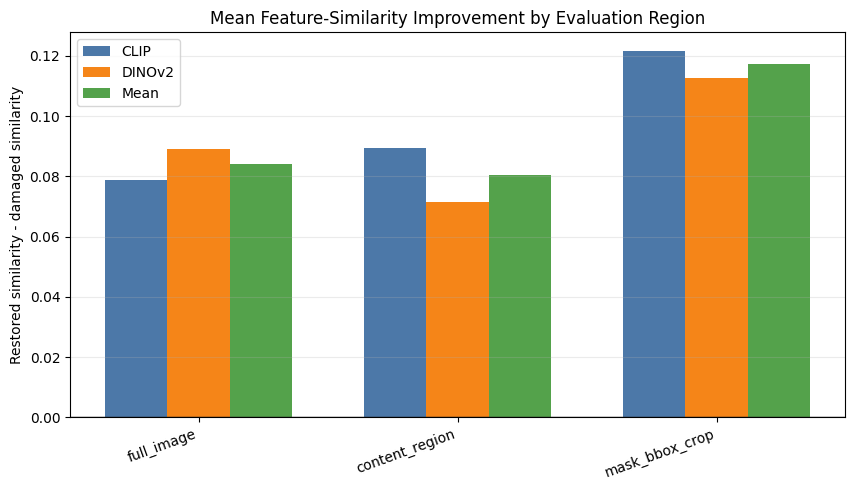

,evaluation_region,mean_clip_similarity_improvement,mean_dinov2_similarity_improvement,mean_similarity_improvement
0,full_image,0.078849,0.088995,0.083922
1,content_region,0.089468,0.071490,0.080479
2,mask_bbox_crop,0.121695,0.112756,0.117225


In [22]:
region_mean_plot_df = (
    feature_plot_df
    .groupby("evaluation_region", observed=False, dropna=False)
    .agg(
        mean_clip_similarity_improvement=("clip_similarity_improvement", "mean"),
        mean_dinov2_similarity_improvement=("dinov2_similarity_improvement", "mean"),
        mean_similarity_improvement=("mean_similarity_improvement", "mean"),
    )
    .reset_index()
)

region_mean_plot_df["evaluation_region"] = region_mean_plot_df["evaluation_region"].astype(str)
region_mean_plot_df = region_mean_plot_df.loc[
    region_mean_plot_df["evaluation_region"].isin(FEATURE_EVALUATION_REGIONS)
].copy()

x_positions = np.arange(len(region_mean_plot_df))
bar_width = 0.24

fig, axis = plt.subplots(figsize=(10, 5))

axis.axhline(0, color="#222222", linewidth=1)

axis.bar(
    x_positions - bar_width,
    region_mean_plot_df["mean_clip_similarity_improvement"],
    width=bar_width,
    label="CLIP",
    color="#4C78A8",
)

axis.bar(
    x_positions,
    region_mean_plot_df["mean_dinov2_similarity_improvement"],
    width=bar_width,
    label="DINOv2",
    color="#F58518",
)

axis.bar(
    x_positions + bar_width,
    region_mean_plot_df["mean_similarity_improvement"],
    width=bar_width,
    label="Mean",
    color="#54A24B",
)

axis.set_title("Mean Feature-Similarity Improvement by Evaluation Region")
axis.set_ylabel("Restored similarity - damaged similarity")
axis.set_xticks(x_positions)
axis.set_xticklabels(region_mean_plot_df["evaluation_region"], rotation=20, ha="right")
axis.legend()
axis.grid(axis="y", alpha=0.25)

save_feature_figure(
    fig,
    figure_id="feature_region_mean_improvement",
    filename="feature_region_mean_improvement_lama.png",
    title="Mean feature-similarity improvement by region",
    description="Grouped bar chart comparing CLIP, DINOv2, and averaged feature-similarity improvement across evaluation regions.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="clip_similarity_improvement; dinov2_similarity_improvement; mean_similarity_improvement",
    rows_used=len(feature_plot_df),
)

display(region_mean_plot_df.round(6))

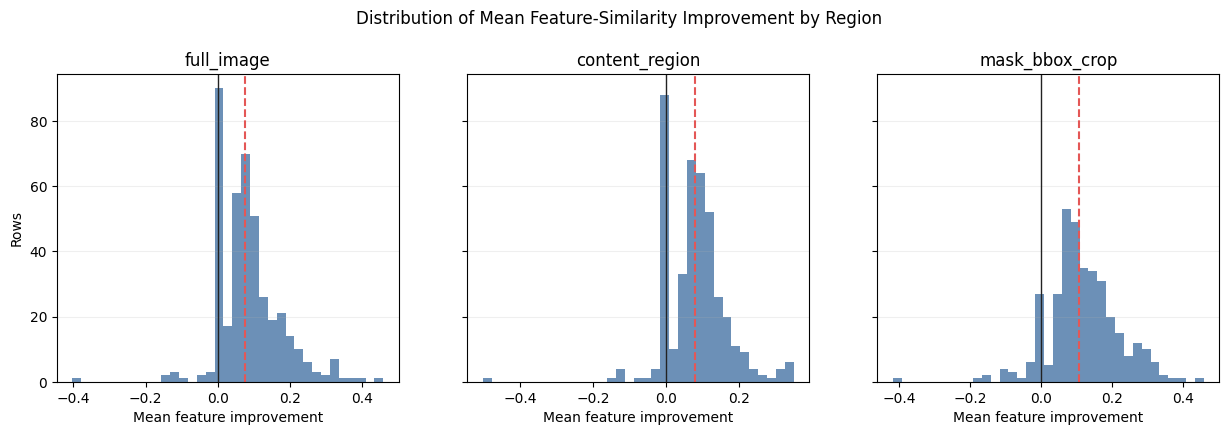

In [23]:
fig, axes = plt.subplots(
    1,
    len(FEATURE_EVALUATION_REGIONS),
    figsize=(15, 4),
    sharey=True,
)

if len(FEATURE_EVALUATION_REGIONS) == 1:
    axes = [axes]

for axis, evaluation_region in zip(axes, FEATURE_EVALUATION_REGIONS):
    region_values = feature_plot_df.loc[
        feature_plot_df["evaluation_region"].astype(str).eq(evaluation_region),
        "mean_similarity_improvement",
    ].dropna()

    axis.hist(region_values, bins=35, color="#4C78A8", alpha=0.82)
    axis.axvline(0, color="#222222", linewidth=1)
    axis.axvline(region_values.median(), color="#E45756", linewidth=1.5, linestyle="--")
    axis.set_title(evaluation_region)
    axis.set_xlabel("Mean feature improvement")
    axis.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Rows")
fig.suptitle("Distribution of Mean Feature-Similarity Improvement by Region", y=1.04)

save_feature_figure(
    fig,
    figure_id="feature_improvement_distribution_by_region",
    filename="feature_improvement_distribution_by_region_lama.png",
    title="Distribution of mean feature-similarity improvement by region",
    description="Histograms showing whether feature similarity usually improves or worsens after LaMa restoration.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="mean_similarity_improvement",
    rows_used=len(feature_plot_df),
)

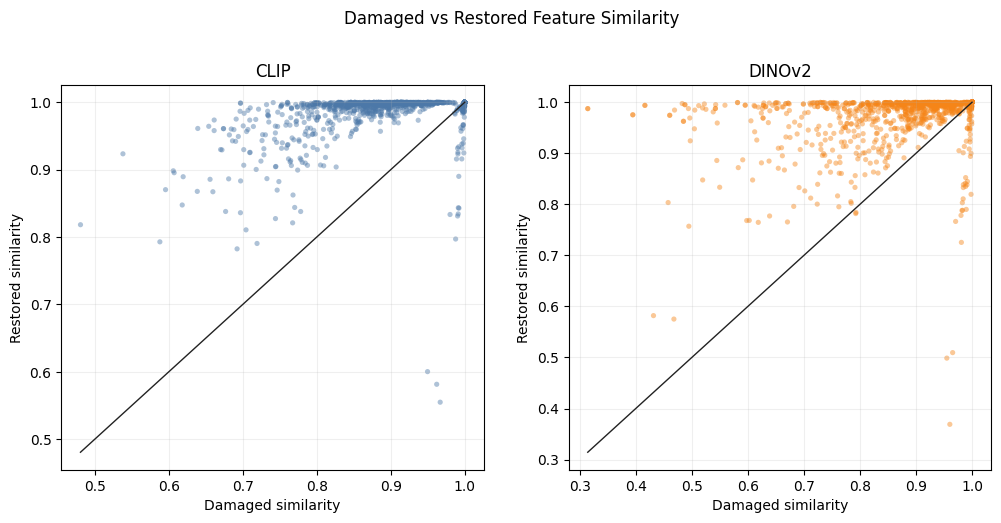

In [24]:
scatter_specs = [
    {
        "model_label": "CLIP",
        "damaged_column": "clip_damaged_similarity",
        "restored_column": "clip_restored_similarity",
        "color": "#4C78A8",
    },
    {
        "model_label": "DINOv2",
        "damaged_column": "dinov2_damaged_similarity",
        "restored_column": "dinov2_restored_similarity",
        "color": "#F58518",
    },
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for axis, spec in zip(axes, scatter_specs):
    damaged_values = feature_plot_df[spec["damaged_column"]]
    restored_values = feature_plot_df[spec["restored_column"]]

    axis.scatter(
        damaged_values,
        restored_values,
        s=14,
        alpha=0.45,
        color=spec["color"],
        edgecolors="none",
    )

    min_value = float(min(damaged_values.min(), restored_values.min()))
    max_value = float(max(damaged_values.max(), restored_values.max()))

    axis.plot([min_value, max_value], [min_value, max_value], color="#222222", linewidth=1)
    axis.set_title(spec["model_label"])
    axis.set_xlabel("Damaged similarity")
    axis.set_ylabel("Restored similarity")
    axis.grid(alpha=0.2)

fig.suptitle("Damaged vs Restored Feature Similarity", y=1.03)

save_feature_figure(
    fig,
    figure_id="feature_damaged_vs_restored_similarity",
    filename="feature_damaged_vs_restored_similarity_lama.png",
    title="Damaged vs restored feature similarity",
    description="Scatter plots where points above the diagonal indicate improved feature similarity after restoration.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="clip_damaged_similarity; clip_restored_similarity; dinov2_damaged_similarity; dinov2_restored_similarity",
    rows_used=len(feature_plot_df),
)

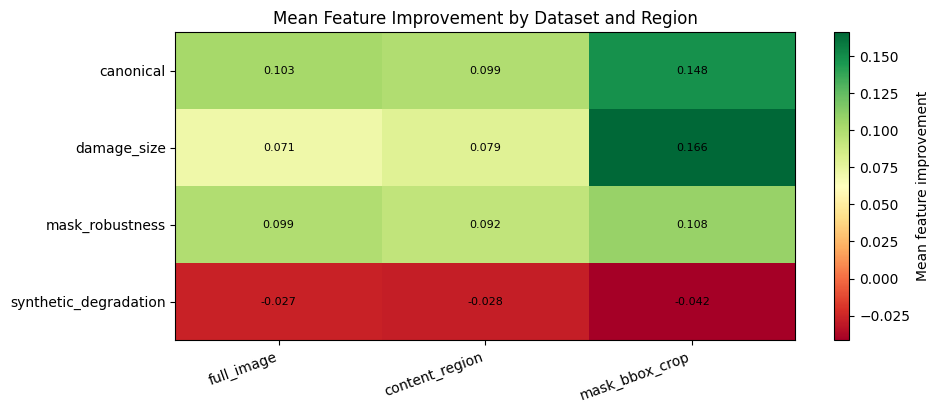

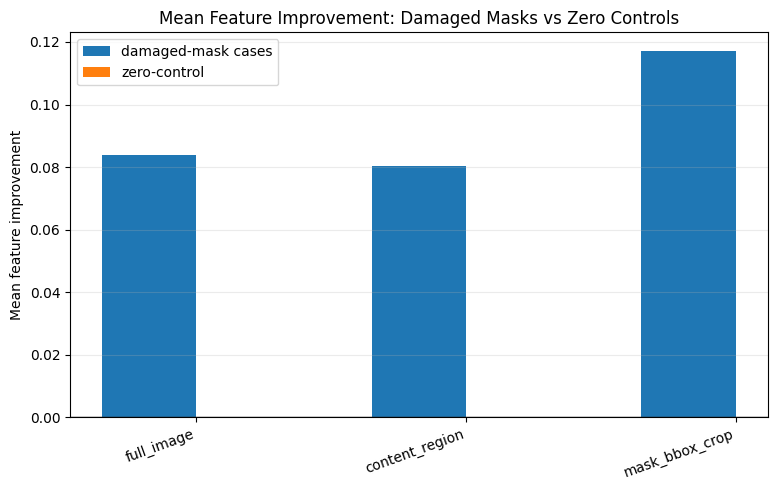

,dataset_name,evaluation_region,mean_similarity_improvement
0,canonical,full_image,0.103299
1,canonical,content_region,0.098846
2,canonical,mask_bbox_crop,0.147759
3,damage_size,full_image,0.070647
4,damage_size,content_region,0.078796
5,damage_size,mask_bbox_crop,0.166040
6,mask_robustness,full_image,0.099393
7,mask_robustness,content_region,0.092454
8,mask_robustness,mask_bbox_crop,0.108365
9,synthetic_degradation,full_image,-0.026875


,is_zero_control,evaluation_region,mean_similarity_improvement
0,False,full_image,0.083922
1,False,content_region,0.080479
2,False,mask_bbox_crop,0.117225


In [25]:
dataset_region_heatmap_df = (
    feature_plot_df
    .groupby(["dataset_name", "evaluation_region"], observed=False, dropna=False)
    .agg(mean_similarity_improvement=("mean_similarity_improvement", "mean"))
    .reset_index()
)

dataset_region_heatmap_df["evaluation_region"] = dataset_region_heatmap_df["evaluation_region"].astype(str)

heatmap_pivot_df = (
    dataset_region_heatmap_df
    .pivot(index="dataset_name", columns="evaluation_region", values="mean_similarity_improvement")
    .reindex(columns=FEATURE_EVALUATION_REGIONS)
)

fig, axis = plt.subplots(figsize=(10, max(4, 0.45 * len(heatmap_pivot_df))))

heatmap_values = heatmap_pivot_df.to_numpy(dtype=float)
image = axis.imshow(heatmap_values, aspect="auto", cmap="RdYlGn")

axis.set_title("Mean Feature Improvement by Dataset and Region")
axis.set_xticks(np.arange(len(heatmap_pivot_df.columns)))
axis.set_xticklabels(heatmap_pivot_df.columns, rotation=20, ha="right")
axis.set_yticks(np.arange(len(heatmap_pivot_df.index)))
axis.set_yticklabels(heatmap_pivot_df.index)

for row_index in range(heatmap_values.shape[0]):
    for column_index in range(heatmap_values.shape[1]):
        value = heatmap_values[row_index, column_index]
        if np.isfinite(value):
            axis.text(column_index, row_index, f"{value:.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=axis, label="Mean feature improvement")

save_feature_figure(
    fig,
    figure_id="feature_dataset_region_heatmap",
    filename="feature_dataset_region_heatmap_lama.png",
    title="Dataset-region feature improvement heatmap",
    description="Heatmap of mean feature-similarity improvement across experiment datasets and evaluation regions.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="mean_similarity_improvement",
    rows_used=len(feature_plot_df),
)

zero_control_plot_df = (
    feature_plot_df
    .groupby(["is_zero_control", "evaluation_region"], observed=False, dropna=False)
    .agg(mean_similarity_improvement=("mean_similarity_improvement", "mean"))
    .reset_index()
)

zero_control_plot_df["evaluation_region"] = zero_control_plot_df["evaluation_region"].astype(str)

fig, axis = plt.subplots(figsize=(9, 5))

x_positions = np.arange(len(FEATURE_EVALUATION_REGIONS))
bar_width = 0.35

for offset, is_zero_control in [(-bar_width / 2, False), (bar_width / 2, True)]:
    subset_df = (
        zero_control_plot_df
        .loc[zero_control_plot_df["is_zero_control"].astype(bool).eq(is_zero_control)]
        .set_index("evaluation_region")
        .reindex(FEATURE_EVALUATION_REGIONS)
    )

    axis.bar(
        x_positions + offset,
        subset_df["mean_similarity_improvement"].to_numpy(dtype=float),
        width=bar_width,
        label="zero-control" if is_zero_control else "damaged-mask cases",
    )

axis.axhline(0, color="#222222", linewidth=1)
axis.set_title("Mean Feature Improvement: Damaged Masks vs Zero Controls")
axis.set_ylabel("Mean feature improvement")
axis.set_xticks(x_positions)
axis.set_xticklabels(FEATURE_EVALUATION_REGIONS, rotation=20, ha="right")
axis.legend()
axis.grid(axis="y", alpha=0.25)

save_feature_figure(
    fig,
    figure_id="feature_zero_control_comparison",
    filename="feature_zero_control_comparison_lama.png",
    title="Zero-control feature-improvement comparison",
    description="Grouped bar chart comparing mean feature improvement for damaged-mask cases and zero-control cases.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="mean_similarity_improvement",
    rows_used=len(feature_plot_df),
)

display(dataset_region_heatmap_df.round(6))
display(zero_control_plot_df.round(6))

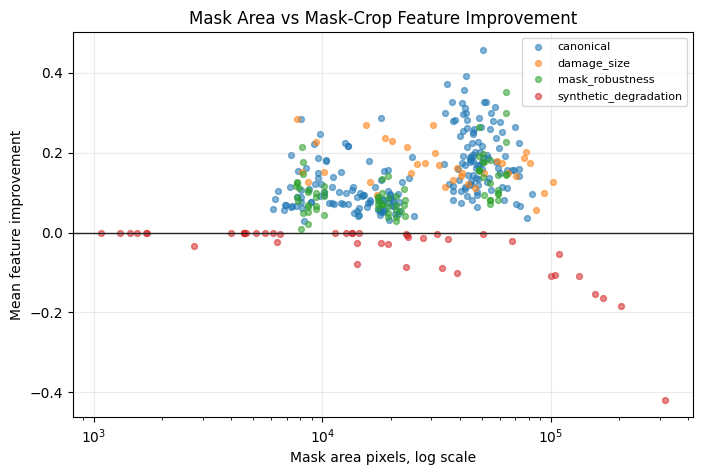

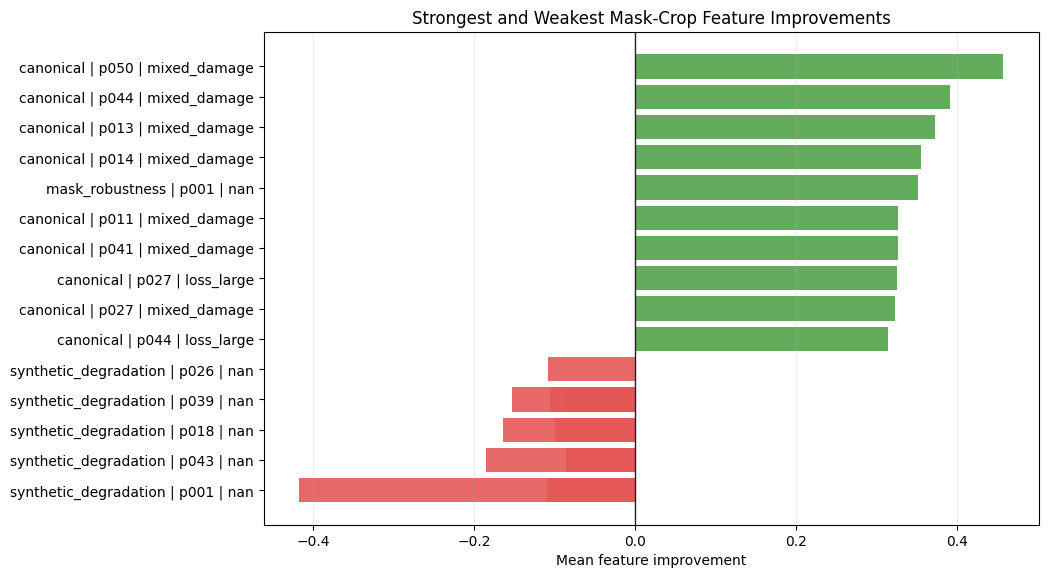

,rank_direction,rank_metric,rank_evaluation_region,rank_position,rank_metric_value,feature_row_id,feature_case_id,restoration_case_id,source_case_id,dataset_name,painting_id,category,title,artist,style,model_name,mask_type,metric_mask_type,evaluation_region,region_pixel_count,mask_area_pixels,is_zero_control,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,mean_similarity_improvement,clean_embedding_id,damaged_embedding_id,restored_embedding_id,embedding_group_id,status,issue,plot_label
340,weakest,mean_similarity_improvement,mask_bbox_crop,1,-0.418186,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe__mask_bbox_crop__feature_similarity,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe,synthetic_degradation__p001__partial_transparency__severe,synthetic_degradation,p001,portrait_figure,Juan de Pareja,Diego Velázquez,Baroque,lama,NaN,NaN,mask_bbox_crop,492804,315211,False,0.962029,0.581471,-0.380558,0.965361,0.509547,-0.455814,-0.418186,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe__mask_bbox_crop__clean,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe__mask_bbox_crop__damaged,lama__synthetic_degradation__synthetic_degradation__p001__partial_transparency__severe__mask_bbox_crop__restored,synthetic_degradation__p001__mask_bbox_crop,ok,NaN,synthetic_degradation | p001 | nan
341,weakest,mean_similarity_improvement,mask_bbox_crop,2,-0.185079,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe__mask_bbox_crop__feature_similarity,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe,synthetic_degradation__p043__partial_transparency__severe,synthetic_degradation,p043,high_texture_brushwork,The Card Players,Paul Cézanne,Post-Impressionism,lama,NaN,NaN,mask_bbox_crop,376996,202937,False,0.987622,0.797014,-0.190609,0.982650,0.803100,-0.179550,-0.185079,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe__mask_bbox_crop__clean,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe__mask_bbox_crop__damaged,lama__synthetic_degradation__synthetic_degradation__p043__partial_transparency__severe__mask_bbox_crop__restored,synthetic_degradation__p043__mask_bbox_crop,ok,NaN,synthetic_degradation | p043 | nan
342,weakest,mean_similarity_improvement,mask_bbox_crop,3,-0.164297,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe__mask_bbox_crop__feature_similarity,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe,synthetic_degradation__p018__partial_transparency__severe,synthetic_degradation,p018,landscape_natural,Classical Landscape with Figures,Henri Mauperché,NaN,lama,NaN,NaN,mask_bbox_crop,265225,169410,False,0.988782,0.915704,-0.073078,0.980959,0.725444,-0.255515,-0.164297,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe__mask_bbox_crop__clean,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe__mask_bbox_crop__damaged,lama__synthetic_degradation__synthetic_degradation__p018__partial_transparency__severe__mask_bbox_crop__restored,synthetic_degradation__p018__mask_bbox_crop,ok,NaN,synthetic_degradation | p018 | nan
343,weakest,mean_similarity_improvement,mask_bbox_crop,4,-0.153039,lama__synthetic_degradation__synthetic_degradation__p039__partial_transparency__severe__mask_bbox_crop__feature_similarity,lama__synthetic_degradation__synthetic_degradation__p039_

In [26]:
mask_area_plot_df = feature_plot_df.loc[
    feature_plot_df["evaluation_region"].astype(str).eq("mask_bbox_crop")
    & feature_plot_df["mask_area_pixels"].notna()
    & feature_plot_df["mask_area_pixels"].gt(0)
].copy()

fig, axis = plt.subplots(figsize=(8, 5))

if mask_area_plot_df.empty:
    axis.text(
        0.5,
        0.5,
        "No positive mask-area rows available.",
        ha="center",
        va="center",
        transform=axis.transAxes,
    )
else:
    for dataset_name in sorted(mask_area_plot_df["dataset_name"].dropna().unique()):
        dataset_df = mask_area_plot_df.loc[
            mask_area_plot_df["dataset_name"].eq(dataset_name)
        ]

        axis.scatter(
            dataset_df["mask_area_pixels"],
            dataset_df["mean_similarity_improvement"],
            s=18,
            alpha=0.55,
            label=dataset_name,
        )

    axis.set_xscale("log")
    axis.axhline(0, color="#222222", linewidth=1)
    axis.legend(fontsize=8)

axis.set_title("Mask Area vs Mask-Crop Feature Improvement")
axis.set_xlabel("Mask area pixels, log scale")
axis.set_ylabel("Mean feature improvement")
axis.grid(alpha=0.25)

save_feature_figure(
    fig,
    figure_id="feature_mask_area_sensitivity",
    filename="feature_mask_area_sensitivity_lama.png",
    title="Mask-area sensitivity diagnostic",
    description="Scatter plot checking whether larger masks systematically change mask-bbox feature-similarity improvement.",
    source_table="feature_similarity_metrics_lama_compact.csv",
    metric="mask_area_pixels; mean_similarity_improvement",
    rows_used=len(mask_area_plot_df),
)

rank_plot_region = "mask_bbox_crop"
rank_plot_metric = "mean_similarity_improvement"
RANK_PLOT_TOP_N_PER_DIRECTION = 10

rank_plot_df = feature_ranked_region_batch5_df.loc[
    feature_ranked_region_batch5_df["rank_evaluation_region"].astype(str).eq(rank_plot_region)
    & feature_ranked_region_batch5_df["rank_metric"].astype(str).eq(rank_plot_metric)
    & feature_ranked_region_batch5_df["rank_direction"].astype(str).isin(["strongest", "weakest"])
].copy()

rank_plot_df = (
    rank_plot_df
    .sort_values(["rank_direction", "rank_position"], kind="stable")
    .groupby("rank_direction", as_index=False, sort=False)
    .head(RANK_PLOT_TOP_N_PER_DIRECTION)
)

rank_plot_df["rank_metric_value"] = pd.to_numeric(
    rank_plot_df["rank_metric_value"],
    errors="coerce",
)

rank_plot_df["plot_label"] = (
    rank_plot_df["dataset_name"].astype(str)
    + " | "
    + rank_plot_df["painting_id"].astype(str)
    + " | "
    + rank_plot_df.get("mask_type", pd.Series([""] * len(rank_plot_df))).astype(str)
).map(short_label)

rank_plot_df = rank_plot_df.sort_values("rank_metric_value", ascending=True, kind="stable")

fig_height = max(6, 0.32 * len(rank_plot_df))
fig, axis = plt.subplots(figsize=(10, fig_height))

bar_colors = np.where(rank_plot_df["rank_metric_value"].ge(0), "#54A24B", "#E45756")

axis.barh(
    rank_plot_df["plot_label"],
    rank_plot_df["rank_metric_value"],
    color=bar_colors,
    alpha=0.9,
)

axis.axvline(0, color="#222222", linewidth=1)
axis.set_title("Strongest and Weakest Mask-Crop Feature Improvements")
axis.set_xlabel("Mean feature improvement")
axis.grid(axis="x", alpha=0.25)

save_feature_figure(
    fig,
    figure_id="feature_mask_crop_ranking_diagnostic",
    filename="feature_mask_crop_ranking_diagnostic_lama.png",
    title="Mask-crop strongest and weakest ranking diagnostic",
    description="Horizontal bar chart of the strongest and weakest mask-bbox cases by mean feature-similarity improvement.",
    source_table="feature_similarity_ranked_cases_by_region_lama.csv",
    metric="mean_similarity_improvement",
    rows_used=len(rank_plot_df),
)

display(rank_plot_df.head(25))

In [27]:
feature_diagnostic_figure_manifest_df = pd.DataFrame(figure_records)

feature_diagnostic_figure_manifest_df.to_csv(
    FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH,
    index=False,
)

expected_figure_ids = [
    "feature_region_mean_improvement",
    "feature_improvement_distribution_by_region",
    "feature_damaged_vs_restored_similarity",
    "feature_dataset_region_heatmap",
    "feature_zero_control_comparison",
    "feature_mask_area_sensitivity",
    "feature_mask_crop_ranking_diagnostic",
]

figure_ids_present = (
    sorted(feature_diagnostic_figure_manifest_df["figure_id"].dropna().unique().tolist())
    if not feature_diagnostic_figure_manifest_df.empty
    else []
)

batch5_validation_df = pd.DataFrame(
    [
        build_check(
            "batch5_preflight_passed",
            bool(batch5_preflight_df["passed"].astype(bool).all()),
            True,
            bool(batch5_preflight_df["passed"].astype(bool).all()),
        ),
        build_check(
            "expected_figures_created",
            figure_ids_present,
            sorted(expected_figure_ids),
            set(figure_ids_present) == set(expected_figure_ids),
        ),
        build_check(
            "figure_files_exist",
            int(feature_diagnostic_figure_manifest_df["exists"].astype(bool).sum()),
            len(feature_diagnostic_figure_manifest_df),
            bool(feature_diagnostic_figure_manifest_df["exists"].astype(bool).all()),
        ),
        build_check(
            "figure_files_nonempty",
            int(feature_diagnostic_figure_manifest_df["size_bytes"].astype(int).gt(0).sum()),
            len(feature_diagnostic_figure_manifest_df),
            bool(feature_diagnostic_figure_manifest_df["size_bytes"].astype(int).gt(0).all()),
        ),
        build_check(
            "figure_manifest_saved",
            FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH.is_file(),
            True,
            FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH.is_file(),
        ),
        build_check(
            "figure_manifest_nonempty",
            len(feature_diagnostic_figure_manifest_df),
            "> 0",
            len(feature_diagnostic_figure_manifest_df) > 0,
        ),
    ]
)

batch5_validation_df.to_csv(FEATURE_BATCH5_VALIDATION_OUTPUT_PATH, index=False)

display(feature_diagnostic_figure_manifest_df)
display(batch5_validation_df)

if not batch5_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 5 diagnostic figure validation failed.")

if FEATURE_STAGE_MANIFEST_JSON_PATH.is_file():
    with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
        feature_stage_manifest = json.load(manifest_file)
else:
    feature_stage_manifest = {}

feature_stage_manifest.setdefault("batches", {})
feature_stage_manifest["batches"]["batch_5"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "diagnostic_plots_figures_and_figure_manifest",
    "validation": project_relative_path(FEATURE_BATCH5_VALIDATION_OUTPUT_PATH),
    "validation_passed": bool(batch5_validation_df["passed"].astype(bool).all()),
    "outputs": {
        "figure_directory": project_relative_path(FEATURE_DIAGNOSTIC_FIGURES_DIR),
        "figure_manifest": project_relative_path(FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH),
        "batch5_validation": project_relative_path(FEATURE_BATCH5_VALIDATION_OUTPUT_PATH),
    },
    "source_tables": {
        "compact_feature_metrics": project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH),
        "dataset_region_summary": project_relative_path(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH),
        "mask_region_summary": project_relative_path(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH),
        "zero_control_summary": project_relative_path(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH),
        "ranked_by_region": project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH),
    },
    "figure_count": int(len(feature_diagnostic_figure_manifest_df)),
    "figures": feature_diagnostic_figure_manifest_df[
        ["figure_id", "title", "relative_path", "metric", "rows_used"]
    ].to_dict(orient="records"),
}

json_default = json_safe if "json_safe" in globals() else str

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_default)

print("Batch 5 complete.")
print("Diagnostic figures:", project_relative_path(FEATURE_DIAGNOSTIC_FIGURES_DIR))
print("Figure manifest:", project_relative_path(FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH))
print("Batch 5 validation:", project_relative_path(FEATURE_BATCH5_VALIDATION_OUTPUT_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))

,figure_id,filename,title,description,source_table,metric,rows_used,path,relative_path,exists,size_bytes,created_at_utc
0,feature_region_mean_improvement,feature_region_mean_improvement_lama.png,Mean feature-similarity improvement by region,"Grouped bar chart comparing CLIP, DINOv2, and averaged feature-similarity improvement across evaluation regions.",feature_similarity_metrics_lama_compact.csv,clip_similarity_improvement; dinov2_similarity_improvement; mean_similarity_improvement,1175,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_re...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_region_mean_improvement_lama.png,True,63452,2026-07-29T12:40:03.907517+00:00
1,feature_improvement_distribution_by_region,feature_improvement_distribution_by_region_lama.png,Distribution of mean feature-similarity improvement by region,Histograms showing whether feature similarity usually improves or worsens after LaMa restoration.,feature_similarity_metrics_lama_compact.csv,mean_similarity_improvement,1175,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_im...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_improvement_distribution_by_region_lama.png,True,50510,2026-07-29T12:40:03.907517+00:00
2,feature_damaged_vs_restored_similarity,feature_damaged_vs_restored_similarity_lama.png,Damaged vs restored feature similarity,Scatter plots where points above the diagonal indicate improved feature similarity after restoration.,feature_similarity_metrics_lama_compact.csv,clip_damaged_similarity; clip_restored_similarity; dinov2_damaged_similarity; dinov2_restored_similarity,1175,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_da...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_damaged_vs_restored_similarity_lama.png,True,167763,2026-07-29T12:40:03.907517+00:00
3,feature_dataset_region_heatmap,feature_dataset_region_heatmap_lama.png,Dataset-region feature improvement heatmap,Heatmap of mean feature-similarity improvement across experiment datasets and evaluation regions.,feature_similarity_metrics_lama_compact.csv,mean_similarity_improvement,1175,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_da...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_dataset_region_heatmap_lama.png,True,85995,2026-07-29T12:40:03.907517+00:00
4,feature_zero_control_comparison,feature_zero_control_comparison_lama.png,Zero-control feature-improvement comparison,Grouped bar chart comparing mean feature improvement for damaged-mask cases and zero-control cases.,feature_similarity_metrics_lama_compact.csv,mean_similarity_improvement,1175,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_ze...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_zero_control_comparison_lama.png,True,63721,2026-07-29T12:40:03.907517+00:00
5,feature_mask_area_sensitivity,feature_mask_area_sensitivity_lama.png,Mask-area sensitivity diagnostic,Scatter plot checking whether larger masks systematically change mask-bbox feature-similarity improvement.,feature_similarity_metrics_lama_compact.csv,mask_area_pixels; mean_similarity_improvement,355,D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\18_lama_feature_similarity\feature_similarity_diagnostics_lama\feature_ma...,outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_mask_area_sensitivity_lama.png,True,105387,2026-07-29T12:40:03.907517+00:00
6,feature_mask_crop_ranking_diagnostic,feature_mask_crop

,check_name,observed,expected,passed,issue
0,batch5_preflight_passed,True,True,True,
1,expected_figures_created,"[feature_damaged_vs_restored_similarity, feature_dataset_region_heatmap, feature_improvement_distribution_by_region, feature_mask_area_s...","[feature_damaged_vs_restored_similarity, feature_dataset_region_heatmap, feature_improvement_distribution_by_region, feature_mask_area_s...",True,
2,figure_files_exist,7,7,True,
3,figure_files_nonempty,7,7,True,
4,figure_manifest_saved,True,True,True,
5,figure_manifest_nonempty,7,> 0,True,


Batch 5 complete.
Diagnostic figures: outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama
Figure manifest: outputs/figures/18_lama_feature_similarity/feature_similarity_diagnostics_lama/feature_similarity_diagnostic_figure_manifest_lama.csv
Batch 5 validation: outputs/validation/feature_similarity_batch5_validation_lama.csv
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json


In [28]:
from datetime import datetime, timezone
from pathlib import Path
import json

import numpy as np
import pandas as pd

if "FEATURE_BATCH4_VALIDATION_OUTPUT_PATH" not in globals():
    FEATURE_BATCH4_VALIDATION_OUTPUT_PATH = (
        VALIDATION_DIR / "feature_similarity_batch4_validation_lama.csv"
    )

if "FEATURE_BATCH5_VALIDATION_OUTPUT_PATH" not in globals():
    FEATURE_BATCH5_VALIDATION_OUTPUT_PATH = (
        VALIDATION_DIR / "feature_similarity_batch5_validation_lama.csv"
    )

required_final_artifact_paths = {
    "raw_metrics": FEATURE_METRICS_OUTPUT_PATH,
    "compact_metrics": FEATURE_COMPACT_METRICS_OUTPUT_PATH,
    "overall_summary": FEATURE_OVERALL_SUMMARY_OUTPUT_PATH,
    "dataset_region_summary": FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH,
    "mask_region_summary": FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH,
    "category_region_summary": FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH,
    "zero_control_summary": FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH,
    "ranked_by_region": FEATURE_RANKED_BY_REGION_OUTPUT_PATH,
    "figure_manifest": FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH,
    "batch1_validation": FEATURE_BATCH1_VALIDATION_OUTPUT_PATH,
    "batch3_validation": FEATURE_FULL_VALIDATION_OUTPUT_PATH,
    "batch4_validation": FEATURE_BATCH4_VALIDATION_OUTPUT_PATH,
    "batch5_validation": FEATURE_BATCH5_VALIDATION_OUTPUT_PATH,
    "stage_manifest": FEATURE_STAGE_MANIFEST_JSON_PATH,
}

missing_final_artifacts = {
    name: project_relative_path(path)
    for name, path in required_final_artifact_paths.items()
    if not path.is_file()
}

if missing_final_artifacts:
    raise RuntimeError(f"Batch 6 missing required artifacts: {missing_final_artifacts}")

feature_raw_final_df = pd.read_csv(FEATURE_METRICS_OUTPUT_PATH)
feature_compact_final_df = pd.read_csv(FEATURE_COMPACT_METRICS_OUTPUT_PATH)
feature_overall_summary_final_df = pd.read_csv(FEATURE_OVERALL_SUMMARY_OUTPUT_PATH)
feature_dataset_region_summary_final_df = pd.read_csv(FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH)
feature_mask_region_summary_final_df = pd.read_csv(FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH)
feature_category_region_summary_final_df = pd.read_csv(FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH)
feature_zero_control_summary_final_df = pd.read_csv(FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH)
feature_ranked_region_final_df = pd.read_csv(FEATURE_RANKED_BY_REGION_OUTPUT_PATH)
feature_figure_manifest_final_df = pd.read_csv(FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH)

batch_validation_tables = {
    "batch1_validation": pd.read_csv(FEATURE_BATCH1_VALIDATION_OUTPUT_PATH),
    "batch3_validation": pd.read_csv(FEATURE_FULL_VALIDATION_OUTPUT_PATH),
    "batch4_validation": pd.read_csv(FEATURE_BATCH4_VALIDATION_OUTPUT_PATH),
    "batch5_validation": pd.read_csv(FEATURE_BATCH5_VALIDATION_OUTPUT_PATH),
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "r", encoding="utf-8") as manifest_file:
    feature_stage_manifest = json.load(manifest_file)

print("Raw metrics shape:", feature_raw_final_df.shape)
print("Compact metrics shape:", feature_compact_final_df.shape)
print("Ranked table shape:", feature_ranked_region_final_df.shape)
print("Figure manifest shape:", feature_figure_manifest_final_df.shape)

Raw metrics shape: (1175, 59)
Compact metrics shape: (1175, 48)
Ranked table shape: (360, 35)
Figure manifest shape: (7, 12)


In [29]:
def validation_passed(table_df: pd.DataFrame) -> bool:
    if "passed" not in table_df.columns:
        return False

    return bool(
        table_df["passed"]
        .map(lambda value: str(value).strip().lower() in {"true", "1", "yes"})
        .all()
    )


def resolve_manifest_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def json_for_csv(value):
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, default=json_safe, sort_keys=True)
    return value


feature_metric_columns = [
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

required_compact_handoff_columns = [
    "feature_row_id",
    "feature_case_id",
    "dataset_name",
    "painting_id",
    "model_name",
    "evaluation_region",
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
    "embedding_group_id",
    "status",
]

missing_compact_handoff_columns = [
    column
    for column in required_compact_handoff_columns
    if column not in feature_compact_final_df.columns
]

ok_raw_final_df = feature_raw_final_df.loc[
    feature_raw_final_df["status"].astype(str).eq("ok")
].copy()

finite_metric_values = bool(
    np.isfinite(
        ok_raw_final_df[feature_metric_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    ).all()
)

stage_batches = feature_stage_manifest.get("batches", {})
required_completed_batches = [f"batch_{batch_number}" for batch_number in range(1, 6)]

stage_batch_validation_status = {
    batch_name: bool(stage_batches.get(batch_name, {}).get("validation_passed", False))
    for batch_name in required_completed_batches
}

batch_validation_status = {
    name: validation_passed(table_df)
    for name, table_df in batch_validation_tables.items()
}

raw_region_counts = {
    key: int(value)
    for key, value in feature_raw_final_df["evaluation_region"].value_counts().to_dict().items()
}

status_counts = {
    key: int(value)
    for key, value in feature_raw_final_df["status"].astype(str).value_counts(dropna=False).to_dict().items()
}

raw_contract = (
    stage_batches
    .get("batch_3", {})
    .get("raw_metric_contract", {})
)

expected_raw_rows = raw_contract.get("expected_rows")
expected_region_counts = raw_contract.get("expected_region_counts", {})

ranking_metrics_expected = [
    "clip_similarity_improvement",
    "dinov2_similarity_improvement",
    "mean_similarity_improvement",
]

ranking_directions_present = sorted(
    feature_ranked_region_final_df["rank_direction"].dropna().astype(str).unique().tolist()
)

ranking_metrics_present = sorted(
    feature_ranked_region_final_df["rank_metric"].dropna().astype(str).unique().tolist()
)

ranking_regions_present = sorted(
    feature_ranked_region_final_df["rank_evaluation_region"].dropna().astype(str).unique().tolist()
)

figure_paths = []

for _, figure_row in feature_figure_manifest_final_df.iterrows():
    if "path" in figure_row and pd.notna(figure_row["path"]):
        figure_paths.append(resolve_manifest_path(figure_row["path"]))
    elif "relative_path" in figure_row and pd.notna(figure_row["relative_path"]):
        figure_paths.append(resolve_manifest_path(figure_row["relative_path"]))

figure_file_status = {
    project_relative_path(path): {
        "exists": path.is_file(),
        "size_bytes": int(path.stat().st_size) if path.is_file() else 0,
    }
    for path in figure_paths
}

final_validation_df = pd.DataFrame(
    [
        build_check(
            "required_artifacts_exist",
            {
                name: path.is_file()
                for name, path in required_final_artifact_paths.items()
            },
            "all true",
            all(path.is_file() for path in required_final_artifact_paths.values()),
        ),
        build_check(
            "required_artifacts_nonempty",
            {
                name: int(path.stat().st_size) if path.is_file() else 0
                for name, path in required_final_artifact_paths.items()
            },
            "all > 0",
            all(path.is_file() and path.stat().st_size > 0 for path in required_final_artifact_paths.values()),
        ),
        build_check(
            "batch_validation_csvs_passed",
            batch_validation_status,
            "all true",
            all(batch_validation_status.values()),
        ),
        build_check(
            "stage_manifest_batches_present",
            sorted(stage_batches.keys()),
            required_completed_batches,
            all(batch_name in stage_batches for batch_name in required_completed_batches),
        ),
        build_check(
            "stage_manifest_batches_validated",
            stage_batch_validation_status,
            "all true",
            all(stage_batch_validation_status.values()),
        ),
        build_check(
            "raw_metric_contract_present",
            raw_contract,
            "batch_3.raw_metric_contract",
            bool(raw_contract),
        ),
        build_check(
            "raw_metrics_row_count",
            len(feature_raw_final_df),
            expected_raw_rows,
            expected_raw_rows is not None and len(feature_raw_final_df) == int(expected_raw_rows),
        ),
        build_check(
            "raw_metrics_region_counts",
            raw_region_counts,
            expected_region_counts,
            {
                key: int(value)
                for key, value in expected_region_counts.items()
            } == raw_region_counts,
        ),
        build_check(
            "raw_status_has_no_errors",
            int(feature_raw_final_df["status"].astype(str).eq("error").sum()),
            0,
            int(feature_raw_final_df["status"].astype(str).eq("error").sum()) == 0,
        ),
        build_check(
            "raw_metric_values_finite",
            finite_metric_values,
            True,
            finite_metric_values,
        ),
        build_check(
            "compact_metrics_row_count",
            len(feature_compact_final_df),
            len(feature_raw_final_df),
            len(feature_compact_final_df) == len(feature_raw_final_df),
        ),
        build_check(
            "compact_handoff_columns_present",
            missing_compact_handoff_columns,
            [],
            len(missing_compact_handoff_columns) == 0,
        ),
        build_check(
            "summary_tables_nonempty",
            {
                "overall": len(feature_overall_summary_final_df),
                "dataset_region": len(feature_dataset_region_summary_final_df),
                "mask_region": len(feature_mask_region_summary_final_df),
                "category_region": len(feature_category_region_summary_final_df),
                "zero_control": len(feature_zero_control_summary_final_df),
            },
            "all > 0",
            all(
                len(table_df) > 0
                for table_df in [
                    feature_overall_summary_final_df,
                    feature_dataset_region_summary_final_df,
                    feature_mask_region_summary_final_df,
                    feature_category_region_summary_final_df,
                    feature_zero_control_summary_final_df,
                ]
            ),
        ),
        build_check(
            "ranking_directions_present",
            ranking_directions_present,
            ["strongest", "weakest"],
            ranking_directions_present == ["strongest", "weakest"],
        ),
        build_check(
            "ranking_metrics_present",
            ranking_metrics_present,
            sorted(ranking_metrics_expected),
            ranking_metrics_present == sorted(ranking_metrics_expected),
        ),
        build_check(
            "ranking_regions_present",
            ranking_regions_present,
            sorted(FEATURE_EVALUATION_REGIONS),
            set(ranking_regions_present) == set(FEATURE_EVALUATION_REGIONS),
        ),
        build_check(
            "figure_manifest_nonempty",
            len(feature_figure_manifest_final_df),
            "> 0",
            len(feature_figure_manifest_final_df) > 0,
        ),
        build_check(
            "figure_files_exist_and_nonempty",
            figure_file_status,
            "all exist and size_bytes > 0",
            all(status["exists"] and status["size_bytes"] > 0 for status in figure_file_status.values()),
        ),
    ]
)

final_validation_export_df = final_validation_df.copy()

for column in ["observed", "expected"]:
    final_validation_export_df[column] = final_validation_export_df[column].map(json_for_csv)

final_validation_export_df.to_csv(FEATURE_FINAL_VALIDATION_OUTPUT_PATH, index=False)

display(final_validation_df)

if not final_validation_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 6 final validation failed.")

,check_name,observed,expected,passed,issue
0,required_artifacts_exist,"{'raw_metrics': True, 'compact_metrics': True, 'overall_summary': True, 'dataset_region_summary': True, 'mask_region_summary': True, 'ca...",all true,True,
1,required_artifacts_nonempty,"{'raw_metrics': 1379909, 'compact_metrics': 1224285, 'overall_summary': 1046, 'dataset_region_summary': 2591, 'mask_region_summary': 321...",all > 0,True,
2,batch_validation_csvs_passed,"{'batch1_validation': True, 'batch3_validation': True, 'batch4_validation': True, 'batch5_validation': True}",all true,True,
3,stage_manifest_batches_present,"[batch_1, batch_2, batch_3, batch_4, batch_5]","[batch_1, batch_2, batch_3, batch_4, batch_5]",True,
4,stage_manifest_batches_validated,"{'batch_1': True, 'batch_2': True, 'batch_3': True, 'batch_4': True, 'batch_5': True}",all true,True,
5,raw_metric_contract_present,"{'cases': 410, 'expected_rows': 1175, 'actual_rows': 1175, 'expected_region_counts': {'full_image': 410, 'content_region': 410, 'mask_bb...",batch_3.raw_metric_contract,True,
6,raw_metrics_row_count,1175,1175,True,
7,raw_metrics_region_counts,"{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}","{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}",True,
8,raw_status_has_no_errors,0,0,True,
9,raw_metric_values_finite,True,True,True,


In [30]:
def artifact_record(name: str, path: Path, artifact_type: str, include_sha256: bool = True) -> dict:
    path = Path(path)
    exists = path.is_file()

    return {
        "name": name,
        "type": artifact_type,
        "relative_path": project_relative_path(path),
        "exists": bool(exists),
        "size_bytes": int(path.stat().st_size) if exists else 0,
        "sha256": sha256_file(path) if exists and include_sha256 else "",
    }


table_shapes = {
    "raw_metrics": {
        "rows": int(len(feature_raw_final_df)),
        "columns": int(len(feature_raw_final_df.columns)),
    },
    "compact_metrics": {
        "rows": int(len(feature_compact_final_df)),
        "columns": int(len(feature_compact_final_df.columns)),
    },
    "overall_summary": {
        "rows": int(len(feature_overall_summary_final_df)),
        "columns": int(len(feature_overall_summary_final_df.columns)),
    },
    "dataset_region_summary": {
        "rows": int(len(feature_dataset_region_summary_final_df)),
        "columns": int(len(feature_dataset_region_summary_final_df.columns)),
    },
    "mask_region_summary": {
        "rows": int(len(feature_mask_region_summary_final_df)),
        "columns": int(len(feature_mask_region_summary_final_df.columns)),
    },
    "category_region_summary": {
        "rows": int(len(feature_category_region_summary_final_df)),
        "columns": int(len(feature_category_region_summary_final_df.columns)),
    },
    "zero_control_summary": {
        "rows": int(len(feature_zero_control_summary_final_df)),
        "columns": int(len(feature_zero_control_summary_final_df.columns)),
    },
    "ranked_by_region": {
        "rows": int(len(feature_ranked_region_final_df)),
        "columns": int(len(feature_ranked_region_final_df.columns)),
    },
    "figure_manifest": {
        "rows": int(len(feature_figure_manifest_final_df)),
        "columns": int(len(feature_figure_manifest_final_df.columns)),
    },
    "final_validation": {
        "rows": int(len(final_validation_export_df)),
        "columns": int(len(final_validation_export_df.columns)),
    },
}

feature_handoff_manifest = {
    "manifest_type": "feature_similarity_handoff",
    "handoff_status": "ready_for_downstream_analysis",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": {
        "id": NOTEBOOK_ID,
        "name": NOTEBOOK_NAME,
        "metric_family": METRIC_FAMILY,
        "model_name": MODEL_NAME,
    },
    "schema": {
        "feature_similarity_metric_schema_version": FEATURE_SIMILARITY_METRIC_SCHEMA_VERSION,
        "evaluation_regions": FEATURE_EVALUATION_REGIONS,
        "feature_metric_columns": feature_metric_columns,
        "compact_handoff_columns": required_compact_handoff_columns,
    },
    "validation": {
        "final_validation_csv": project_relative_path(FEATURE_FINAL_VALIDATION_OUTPUT_PATH),
        "final_validation_passed": bool(final_validation_df["passed"].astype(bool).all()),
        "checks": int(len(final_validation_df)),
        "failed_checks": int((~final_validation_df["passed"].astype(bool)).sum()),
    },
    "contracts": {
        "raw_metric_contract": raw_contract,
        "status_counts": status_counts,
        "region_counts": raw_region_counts,
        "ranking_metrics": ranking_metrics_expected,
        "ranking_regions": FEATURE_EVALUATION_REGIONS,
        "ranking_directions": ["strongest", "weakest"],
    },
    "artifacts": {
        "raw_metrics": artifact_record("raw_metrics", FEATURE_METRICS_OUTPUT_PATH, "csv"),
        "compact_metrics": artifact_record("compact_metrics", FEATURE_COMPACT_METRICS_OUTPUT_PATH, "csv"),
        "overall_summary": artifact_record("overall_summary", FEATURE_OVERALL_SUMMARY_OUTPUT_PATH, "csv"),
        "dataset_region_summary": artifact_record("dataset_region_summary", FEATURE_DATASET_REGION_SUMMARY_OUTPUT_PATH, "csv"),
        "mask_region_summary": artifact_record("mask_region_summary", FEATURE_MASK_REGION_SUMMARY_OUTPUT_PATH, "csv"),
        "category_region_summary": artifact_record("category_region_summary", FEATURE_CATEGORY_REGION_SUMMARY_OUTPUT_PATH, "csv"),
        "zero_control_summary": artifact_record("zero_control_summary", FEATURE_ZERO_CONTROL_SUMMARY_OUTPUT_PATH, "csv"),
        "ranked_by_region": artifact_record("ranked_by_region", FEATURE_RANKED_BY_REGION_OUTPUT_PATH, "csv"),
        "figure_manifest": artifact_record("figure_manifest", FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH, "csv"),
        "final_validation": artifact_record("final_validation", FEATURE_FINAL_VALIDATION_OUTPUT_PATH, "csv"),
        "stage_manifest": artifact_record("stage_manifest", FEATURE_STAGE_MANIFEST_JSON_PATH, "json"),
        "helper_module": artifact_record("helper_module", HELPER_MODULE_PATH, "python"),
    },
    "table_shapes": table_shapes,
    "figures": feature_figure_manifest_final_df[
        [
            column
            for column in [
                "figure_id",
                "title",
                "relative_path",
                "metric",
                "rows_used",
                "size_bytes",
            ]
            if column in feature_figure_manifest_final_df.columns
        ]
    ].to_dict(orient="records"),
    "upstream": {
        "lama_restoration_manifest": project_relative_path(LAMA_RESTORATION_MANIFEST_PATH),
        "lpips_handoff_manifest": project_relative_path(LPIPS_HANDOFF_MANIFEST_JSON_PATH),
        "lpips_handoff_status": lpips_handoff_manifest.get("handoff_status", "")
        if "lpips_handoff_manifest" in globals()
        else "not_loaded_in_this_kernel",
    },
    "recommended_downstream_inputs": {
        "primary_case_level_table": project_relative_path(FEATURE_COMPACT_METRICS_OUTPUT_PATH),
        "raw_audit_table": project_relative_path(FEATURE_METRICS_OUTPUT_PATH),
        "ranked_cases": project_relative_path(FEATURE_RANKED_BY_REGION_OUTPUT_PATH),
        "diagnostic_figures": project_relative_path(FEATURE_DIAGNOSTIC_FIGURE_MANIFEST_PATH),
    },
    "downstream_use_notes": [
        "Use compact_metrics for grouped analysis and cross-metric joins.",
        "Use raw_metrics when runtime, model metadata, or full audit columns are needed.",
        "Use ranked_by_region for representative examples and strongest/weakest case inspection.",
        "Use evaluation_region to keep full-image, content-region, and mask-crop evidence separate.",
    ],
}

feature_stage_manifest.setdefault("batches", {})
feature_stage_manifest["batches"]["batch_6"] = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "final_validation_csv_and_json_handoff_manifest",
    "validation": project_relative_path(FEATURE_FINAL_VALIDATION_OUTPUT_PATH),
    "validation_passed": bool(final_validation_df["passed"].astype(bool).all()),
    "outputs": {
        "final_validation": project_relative_path(FEATURE_FINAL_VALIDATION_OUTPUT_PATH),
        "handoff_manifest": project_relative_path(FEATURE_HANDOFF_MANIFEST_JSON_PATH),
    },
    "handoff_status": "ready_for_downstream_analysis",
    "table_shapes": table_shapes,
}

with open(FEATURE_STAGE_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_stage_manifest, manifest_file, indent=2, default=json_safe)

feature_handoff_manifest["artifacts"]["stage_manifest"] = artifact_record(
    "stage_manifest",
    FEATURE_STAGE_MANIFEST_JSON_PATH,
    "json",
)

with open(FEATURE_HANDOFF_MANIFEST_JSON_PATH, "w", encoding="utf-8") as manifest_file:
    json.dump(feature_handoff_manifest, manifest_file, indent=2, default=json_safe)

handoff_validation_df = pd.DataFrame(
    [
        build_check(
            "handoff_manifest_saved",
            FEATURE_HANDOFF_MANIFEST_JSON_PATH.is_file(),
            True,
            FEATURE_HANDOFF_MANIFEST_JSON_PATH.is_file(),
        ),
        build_check(
            "handoff_manifest_nonempty",
            FEATURE_HANDOFF_MANIFEST_JSON_PATH.stat().st_size if FEATURE_HANDOFF_MANIFEST_JSON_PATH.is_file() else 0,
            "> 0",
            FEATURE_HANDOFF_MANIFEST_JSON_PATH.is_file()
            and FEATURE_HANDOFF_MANIFEST_JSON_PATH.stat().st_size > 0,
        ),
        build_check(
            "handoff_status_ready",
            feature_handoff_manifest["handoff_status"],
            "ready_for_downstream_analysis",
            feature_handoff_manifest["handoff_status"] == "ready_for_downstream_analysis",
        ),
    ]
)

final_validation_with_handoff_df = pd.concat(
    [final_validation_df, handoff_validation_df],
    ignore_index=True,
    sort=False,
)

final_validation_with_handoff_export_df = final_validation_with_handoff_df.copy()

for column in ["observed", "expected"]:
    final_validation_with_handoff_export_df[column] = (
        final_validation_with_handoff_export_df[column].map(json_for_csv)
    )

final_validation_with_handoff_export_df.to_csv(
    FEATURE_FINAL_VALIDATION_OUTPUT_PATH,
    index=False,
)

display(final_validation_with_handoff_df)

if not final_validation_with_handoff_df["passed"].astype(bool).all():
    raise RuntimeError("Batch 6 handoff validation failed.")

print("Batch 6 complete.")
print("Final validation:", project_relative_path(FEATURE_FINAL_VALIDATION_OUTPUT_PATH))
print("Handoff manifest:", project_relative_path(FEATURE_HANDOFF_MANIFEST_JSON_PATH))
print("Stage manifest:", project_relative_path(FEATURE_STAGE_MANIFEST_JSON_PATH))
print("Handoff status:", feature_handoff_manifest["handoff_status"])

,check_name,observed,expected,passed,issue
0,required_artifacts_exist,"{'raw_metrics': True, 'compact_metrics': True, 'overall_summary': True, 'dataset_region_summary': True, 'mask_region_summary': True, 'ca...",all true,True,
1,required_artifacts_nonempty,"{'raw_metrics': 1379909, 'compact_metrics': 1224285, 'overall_summary': 1046, 'dataset_region_summary': 2591, 'mask_region_summary': 321...",all > 0,True,
2,batch_validation_csvs_passed,"{'batch1_validation': True, 'batch3_validation': True, 'batch4_validation': True, 'batch5_validation': True}",all true,True,
3,stage_manifest_batches_present,"[batch_1, batch_2, batch_3, batch_4, batch_5]","[batch_1, batch_2, batch_3, batch_4, batch_5]",True,
4,stage_manifest_batches_validated,"{'batch_1': True, 'batch_2': True, 'batch_3': True, 'batch_4': True, 'batch_5': True}",all true,True,
5,raw_metric_contract_present,"{'cases': 410, 'expected_rows': 1175, 'actual_rows': 1175, 'expected_region_counts': {'full_image': 410, 'content_region': 410, 'mask_bb...",batch_3.raw_metric_contract,True,
6,raw_metrics_row_count,1175,1175,True,
7,raw_metrics_region_counts,"{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}","{'full_image': 410, 'content_region': 410, 'mask_bbox_crop': 355}",True,
8,raw_status_has_no_errors,0,0,True,
9,raw_metric_values_finite,True,True,True,


Batch 6 complete.
Final validation: outputs/validation/feature_similarity_final_validation_lama.csv
Handoff manifest: outputs/metrics/feature_similarity_handoff_manifest_lama.json
Stage manifest: outputs/manifests/18_lama_feature_similarity_manifest.json
Handoff status: ready_for_downstream_analysis
